# Trabajo Práctico N° 2 — Análisis de Series Temporales

## Modelos de Machine Learning para el pronóstico de los ingresos diarios de taxis verdes y Uber en Williamsburg y Midtown Center, Nueva York

**Maestría en Ciencia de Datos — Universidad Austral**

Materia: Análisis de Series Temporales

— Docentes: Rodrigo Del Rosso, Sebastián Calcagno, Braian Drago

Integrantes del grupo:
- Cacabelos, Martín
- Maxwell, Julia
- Nuñez, Keiver
- Sandagorda, Patricia
- Tello, Carmen

---

## 1. Configuración del entorno

Esta sección detecta el entorno de ejecución (Colab o local), instala las dependencias que falten,
importa las librerías y define las rutas de trabajo.

In [ ]:
# --- Detección de entorno y montaje de Google Drive ---
try:
    from google.colab import drive
    drive.mount('/content/drive')
    EN_COLAB = True
except Exception:
    EN_COLAB = False
    print('Entorno local detectado: se omite el montaje de Google Drive.')

: 

In [2]:
import sys
import subprocess
import importlib.util

PAQUETES = {
    'great_tables': 'great_tables',
    'pmdarima': 'pmdarima',
    'holidays': 'holidays',
    'arch': 'arch',
    'lightgbm': 'lightgbm',
    'xgboost': 'xgboost',
}

faltantes = [pip_name for pip_name, modulo in PAQUETES.items()
             if importlib.util.find_spec(modulo) is None]

if faltantes:
    print(f'Instalando: {", ".join(faltantes)}')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *faltantes], check=False)
else:
    print('Todas las dependencias ya están instaladas.')

Instalando: great_tables, pmdarima, arch


In [3]:
import hashlib
import itertools
import json
import pathlib
import pickle
import warnings
import urllib.request
import zipfile
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import holidays
from scipy.stats import boxcox
from great_tables import GT, style, loc, md

from statsmodels.tsa.stattools import adfuller, kpss, acovf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from arch.unitroot import PhillipsPerron
from pmdarima.arima.seasonality import OCSBTest, CHTest

from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore', category=ConvergenceWarning)

PERIODO_ESTACIONAL = 7
VENTANA_MOVIL = 7

In [ ]:
"""
# --- Rutas de trabajo ---
COLAB_DIR = pathlib.Path('/content/drive/MyDrive/Maestría en Ciencia de Datos - Universidad Austral/Materias/15. Análisis de series temporales (jueves)/Trabajo Final')
LOCAL_DIR = pathlib.Path('G:/Mi unidad/Maestría en Ciencia de Datos - Universidad Austral/Materias/15. Análisis de series temporales (jueves)/Trabajo Final')

DATA_DIR = (COLAB_DIR if EN_COLAB else LOCAL_DIR) / 'data'
RAW_DIR = DATA_DIR / 'raw'
CACHE_DIR = DATA_DIR / 'cache'

# Los directorios se crean ANTES de verificar los archivos que viven adentro.
for directorio in (DATA_DIR, RAW_DIR, CACHE_DIR):
    directorio.mkdir(parents=True, exist_ok=True)

ARCHIVOS = {
    'taxi_verde_williamsburg': [
        RAW_DIR / 'green_taxi_williamsburg_trips_24-25.csv',
        RAW_DIR / 'green_taxi_williamsburg_trips_25-26.csv',
    ],
    'uber_williamsburg': [
        RAW_DIR / 'uber_williamsburg_trips_24-25.csv',
        RAW_DIR / 'uber_williamsburg_trips_25-26.csv',
    ],
    'uber_midtown': [
        RAW_DIR / 'uber_midtown_center_trips_24-25.csv',
        RAW_DIR / 'uber_midtown_center_trips_25-26.csv',
    ],
}

print(f'Directorio de datos: {DATA_DIR}')
print('Archivos crudos:')
for nombre, rutas in ARCHIVOS.items():
    for ruta in rutas:
        estado = 'OK' if ruta.exists() else 'NO ENCONTRADO'
        print(f'  {nombre}: {ruta.name} [{estado}]')

"""

In [ ]:
# Validación del entorno - Se fuerza el uso del almacenamiento local temporal
DATA_DIR = pathlib.Path('/content')
RAW_DIR = DATA_DIR
CACHE_DIR = DATA_DIR / 'cache'

# Asegurar existencia del directorio de caché local
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# URLs de GitHub (carpetas de raw y data)
GITHUB_RAW_BASE = "https://raw.githubusercontent.com/keivernunez/analisis_series_temporales_austral/main/TP2/raw/"
GITHUB_DATA_BASE = "https://raw.githubusercontent.com/keivernunez/analisis_series_temporales_austral/main/TP2/data/"

# Definir nombres de archivos esperados localmente (CSV)
NOMBRES_ARCHIVOS = {
    'taxi_verde_williamsburg': [
        'green_taxi_williamsburg_trips_24-25.csv',
        'green_taxi_williamsburg_trips_25-26.csv',
    ],
    'uber_williamsburg': [
        'uber_williamsburg_trips_24-25.csv',
        'uber_williamsburg_trips_25-26.csv',
    ],
    'uber_midtown': [
        'uber_midtown_center_trips_24-25.csv',
        'uber_midtown_center_trips_25-26.csv',
    ],
}

# Descarga y descompresión de archivos si no existen localmente
print('Verificando y descargando archivos desde GitHub:')
ARCHIVOS = {}
for nombre, archivos_lista in NOMBRES_ARCHIVOS.items():
    ARCHIVOS[nombre] = []
    for arch_nombre in archivos_lista:
        dest_path = RAW_DIR / arch_nombre
        ARCHIVOS[nombre].append(dest_path)

        if not dest_path.exists():
            # Intentar descargar directamente el .zip desde el repo
            zip_nombre = arch_nombre.replace('.csv', '.zip')
            url_zip = f"{GITHUB_RAW_BASE}{zip_nombre}"
            zip_dest_path = RAW_DIR / zip_nombre

            print(f'  Descargando y descomprimiendo {zip_nombre} desde GitHub...')
            try:
                urllib.request.urlretrieve(url_zip, zip_dest_path)
                with zipfile.ZipFile(zip_dest_path, 'r') as zip_ref:
                    zip_ref.extractall(RAW_DIR)
                print(f'    -> Extraído correctamente en {dest_path} [OK]')
                # Limpiar el archivo .zip descargado
                if zip_dest_path.exists():
                    os.remove(zip_dest_path)
            except Exception as e_zip:
                # Si falla el zip, intentar con el csv crudo directamente por si acaso
                print(f'    -> No se pudo procesar como .zip ({e_zip}). Intentando descargar .csv directo...')
                url_csv = f"{GITHUB_RAW_BASE}{arch_nombre}"
                try:
                    urllib.request.urlretrieve(url_csv, dest_path)
                    print(f'    -> Guardado directo {arch_nombre} [OK]')
                except Exception as e_csv:
                    print(f'    -> Error al descargar {arch_nombre}: {e_csv}')
        else:
            print(f'  {arch_nombre} ya existe localmente [OK]')

# Descarga de ingresos_diarios.csv de data si no existe localmente
RUTA_INGRESOS = DATA_DIR / 'ingresos_diarios.csv'
if not RUTA_INGRESOS.exists():
    url_ingresos = f"{GITHUB_DATA_BASE}ingresos_diarios.csv"
    print(f'\nDescargando ingresos_diarios.csv desde GitHub...')
    try:
        urllib.request.urlretrieve(url_ingresos, RUTA_INGRESOS)
        print(f'  -> Guardado en {RUTA_INGRESOS} [OK]')
    except Exception as e:
        print(f'  -> Error al descargar ingresos_diarios.csv: {e}')
else:
    print(f'\ningresos_diarios.csv ya existe localmente [OK]')

: 

## 2. Construcción de la serie diaria de ingresos (01/06/2024 – 31/05/2026)

In [7]:
FECHA_INICIO = '2024-06-01'
FECHA_FIN = '2026-05-31'
RANGO_FECHAS = pd.date_range(FECHA_INICIO, FECHA_FIN, freq='D')

RUTA_INGRESOS = DATA_DIR / 'ingresos_diarios.csv'
FORZAR_RECALCULO = False  # cambiar a True si se modifican los CSV originales


def ingreso_diario(rutas_csv, columna_valor, columna_fecha='pickup_date', chunksize=250_000):
    """Agrega por día, en bloques, la columna monetaria indicada.

    Admite una ruta única o una lista de rutas (distintos vintages del mismo
    recorte geográfico), que se concatenan antes de reindexar contra el
    rango de fechas completo.
    """
    if isinstance(rutas_csv, (str, pathlib.Path)):
        rutas_csv = [rutas_csv]

    acumulado = pd.Series(0.0, index=RANGO_FECHAS)
    for ruta_csv in rutas_csv:
        lector = pd.read_csv(
            ruta_csv,
            usecols=[columna_fecha, columna_valor],
            parse_dates=[columna_fecha],
            chunksize=chunksize,
        )
        for bloque in lector:
            suma_bloque = bloque.groupby(columna_fecha)[columna_valor].sum()
            acumulado = acumulado.add(suma_bloque, fill_value=0.0)
    return acumulado.reindex(RANGO_FECHAS, fill_value=0.0)


if RUTA_INGRESOS.exists() and not FORZAR_RECALCULO:
    ingresos = pd.read_csv(RUTA_INGRESOS, index_col=0, parse_dates=True)
    print(f'Serie leída desde caché: {RUTA_INGRESOS.name}')
else:
    ingresos = pd.DataFrame({
        'taxi_verde_williamsburg': ingreso_diario(ARCHIVOS['taxi_verde_williamsburg'], 'total_amount'),
        'uber_williamsburg': ingreso_diario(ARCHIVOS['uber_williamsburg'], 'costo_total'),
        'uber_midtown': ingreso_diario(ARCHIVOS['uber_midtown'], 'costo_total'),
    })
    ingresos.index.name = 'fecha'
    ingresos.to_csv(RUTA_INGRESOS)
    print(f'Serie construida desde los CSV crudos y guardada en: {RUTA_INGRESOS.name}')

ingresos.index.name = 'fecha'

# `df` es la serie diaria en su escala original, con frecuencia diaria explícita.
df = ingresos.asfreq('D')

assert df.index.min() == pd.Timestamp(FECHA_INICIO) and df.index.max() == pd.Timestamp(FECHA_FIN), \
    'El rango de fechas cargado no coincide con el esperado (2024-06-01 a 2026-05-31).'

print(f'Serie diaria: {df.shape[0]} días, {df.shape[1]} series')
df.head()

Serie leída desde caché: ingresos_diarios.csv
Serie diaria: 730 días, 3 series


,taxi_verde_williamsburg,uber_williamsburg,uber_midtown
fecha,,,
2024-06-01,291.40,339938.85,162255.10
2024-06-02,480.02,254645.27,113694.65
2024-06-03,0.00,106596.77,280473.49
2024-06-04,72.30,105553.50,408520.92
2024-06-05,88.96,124873.13,477617.80


## 3. Configuración de las series

Todo el notebook se apoya en un único diccionario `SERIES`. Ahí se define, para cada serie, su
etiqueta para gráficos y tablas y la transformación de estabilización de varianza que se le aplica.
Los diccionarios auxiliares (`COLUMNAS_ORIGINALES`, `COLUMNAS_MODELO`) se derivan de él, de modo que
**las claves de las series nunca cambian a lo largo del notebook** y las celdas se pueden volver a
ejecutar en cualquier orden.

In [8]:
SERIES = {
    'taxi_verde_williamsburg': {
        'etiqueta': 'Taxi verde — Williamsburg',
        'transformacion': 'ninguna',
    },
    'uber_williamsburg': {
        'etiqueta': 'Uber — Williamsburg',
        'transformacion': 'ninguna',
    },
    'uber_midtown': {
        'etiqueta': 'Uber — Midtown Center',
        'transformacion': 'log1p',
    },
}

TRANSFORMACIONES = {
    'ninguna': (lambda x: x, lambda x: x),
    'log1p': (np.log1p, np.expm1),
    'sqrt': (np.sqrt, np.square),
}

SUFIJOS = {'ninguna': '', 'log1p': '_log1p', 'sqrt': '_sqrt'}


def columna_modelo(serie):
    """Nombre de la columna sobre la que efectivamente se modela la serie."""
    return f'{serie}{SUFIJOS[SERIES[serie]["transformacion"]]}'


def transformar(serie, valores):
    return TRANSFORMACIONES[SERIES[serie]['transformacion']][0](valores)


def destransformar(serie, valores):
    """Devuelve los valores a la escala original (ingresos en dólares)."""
    return TRANSFORMACIONES[SERIES[serie]['transformacion']][1](valores)


# Diccionarios derivados: {columna: etiqueta}
COLUMNAS_ORIGINALES = {serie: cfg['etiqueta'] for serie, cfg in SERIES.items()}
COLUMNAS_MODELO = {
    columna_modelo(serie): (cfg['etiqueta'] if cfg['transformacion'] == 'ninguna'
                            else f'{cfg["etiqueta"]} ({cfg["transformacion"]})')
    for serie, cfg in SERIES.items()
}

for serie, cfg in SERIES.items():
    print(f'{serie:28s} -> columna de modelado: {columna_modelo(serie):36s} '
          f'transformación: {cfg["transformacion"]}')

taxi_verde_williamsburg      -> columna de modelado: taxi_verde_williamsburg              transformación: ninguna
uber_williamsburg            -> columna de modelado: uber_williamsburg                    transformación: ninguna
uber_midtown                 -> columna de modelado: uber_midtown_log1p                   transformación: log1p


#### Gráfico 1. Evolución temporal, media móvil y varianza móvil (ventana de 7 días) de los ingresos diarios, 06/2024–05/2026

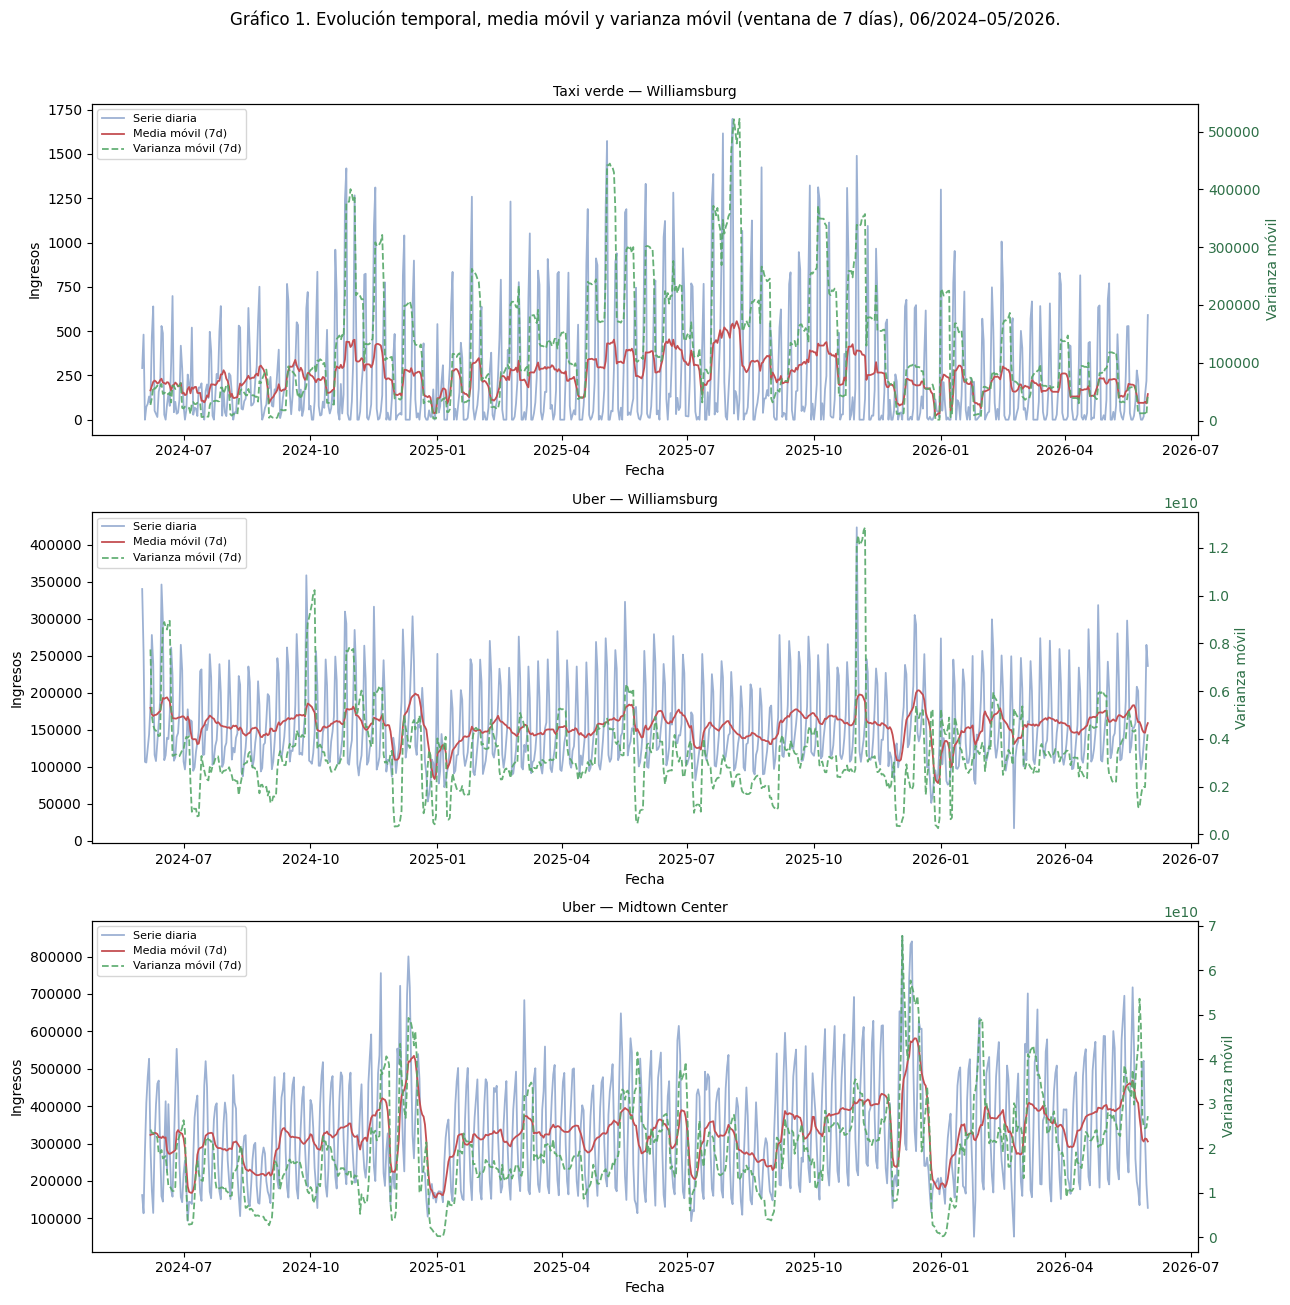

In [9]:
fig, axes = plt.subplots(nrows=len(COLUMNAS_ORIGINALES), ncols=1, figsize=(13, 13))

for ax1, (col, titulo) in zip(axes, COLUMNAS_ORIGINALES.items()):
    serie = df[col]
    media_movil = serie.rolling(VENTANA_MOVIL).mean()
    var_movil = serie.rolling(VENTANA_MOVIL).var()

    ax1.plot(serie.index, serie.values, lw=1.3, alpha=0.55, color='#4C72B0', label='Serie diaria')
    ax1.plot(serie.index, media_movil, lw=1.3, color='#C44E52', label=f'Media móvil ({VENTANA_MOVIL}d)')
    ax1.set_ylabel('Ingresos')
    ax1.set_xlabel('Fecha')

    ax2 = ax1.twinx()
    ax2.plot(serie.index, var_movil, lw=1.3, color='#55A868', alpha=0.9,
             linestyle='--', label=f'Varianza móvil ({VENTANA_MOVIL}d)')
    ax2.set_ylabel('Varianza móvil', color='#2E7047')
    ax2.tick_params(axis='y', labelcolor='#2E7047')

    lineas1, etiquetas1 = ax1.get_legend_handles_labels()
    lineas2, etiquetas2 = ax2.get_legend_handles_labels()
    ax1.legend(lineas1 + lineas2, etiquetas1 + etiquetas2, loc='upper left', fontsize=8)

    ax1.set_title(titulo, fontsize=10)

fig.suptitle('Gráfico 1. Evolución temporal, media móvil y varianza móvil (ventana de 7 días), 06/2024–05/2026.',
             fontsize=12, y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## 4. Estabilización de la varianza

Se combinan dos diagnósticos sobre las series en su escala original: el método Rango-Mediana
(regresión de ln(Rango) sobre ln(Mediana), donde λ ≈ 1 − pendiente) y la estimación de λ por máxima
verosimilitud de Box-Cox con su intervalo de confianza al 95%.

In [10]:
def analyze_rango_mediana(series, window_size=VENTANA_MOVIL):
    """Divide la serie en subgrupos, calcula rango y mediana,
    y ajusta: ln(Rango) = a + b * ln(Mediana).

    Descarta los subgrupos con mediana o rango <= 0, que no admiten logaritmo.
    """
    n = len(series)
    num_groups = n // window_size
    medianas, rangos = [], []

    for i in range(num_groups):
        subgroup = series[i * window_size:(i + 1) * window_size]
        medianas.append(np.median(subgroup))
        rangos.append(np.max(subgroup) - np.min(subgroup))

    medianas, rangos = np.array(medianas), np.array(rangos)

    mask = (medianas > 0) & (rangos > 0)
    n_descartados = int((~mask).sum())
    if n_descartados > 0:
        print(f'  [aviso] se descartaron {n_descartados} de {len(medianas)} subgrupos por mediana o rango <= 0')
    medianas, rangos = medianas[mask], rangos[mask]

    log_medianas, log_rangos = np.log(medianas), np.log(rangos)
    slope, intercept = np.polyfit(log_medianas, log_rangos, 1)

    y_pred = slope * log_medianas + intercept
    r_squared = 1 - (np.sum((log_rangos - y_pred) ** 2) / np.sum((log_rangos - np.mean(log_rangos)) ** 2))

    return {
        'medianas': medianas, 'rangos': rangos, 'intercept': intercept,
        'slope': slope, 'r_squared': r_squared, 'lambda_empirico': 1 - slope,
    }


def calcular_shift(series, margen=1.0):
    """Corrimiento fijo y explícito para series con valores <= 0 (Box-Cox lo requiere)."""
    minimo = np.min(series)
    return (-minimo + margen) if minimo <= 0 else 0.0


def get_boxcox_ci(series, alpha=0.05):
    """Lambda óptimo por MLE y su IC al (1-alpha) usando scipy.stats.boxcox.

    Aplica el corrimiento automáticamente si la serie tiene valores <= 0. Ese
    corrimiento afecta el λ estimado, así que el resultado es orientativo para
    las series con ceros (taxi verde).
    """
    shift = calcular_shift(series)
    series_shifted = np.asarray(series, dtype=float) + shift

    _, l_opt, ci = boxcox(series_shifted, alpha=alpha)
    ci_lower, ci_upper = ci

    return l_opt, ci_lower, ci_upper, shift


filas = []
for col, titulo in COLUMNAS_ORIGINALES.items():
    serie_valores = df[col].dropna().values

    rm = analyze_rango_mediana(serie_valores)
    l_opt, ci_inf, ci_sup, shift = get_boxcox_ci(serie_valores)

    filas.append({
        'Serie': titulo,
        'Pendiente (b)': rm['slope'],
        'R² (Ajuste empírico)': rm['r_squared'],
        'Lambda Empírico (1-b)': rm['lambda_empirico'],
        'Lambda Óptimo (MLE)': l_opt,
        'IC 95% Inferior': ci_inf,
        'IC 95% Superior': ci_sup,
    })

tabla_varianza = pd.DataFrame(filas)

(
    GT(tabla_varianza)
    .tab_header(
        title=f'Tabla 1. Estabilización de varianza: Rango-Mediana (ventana={VENTANA_MOVIL}) vs. Box-Cox MLE'
    )
    .fmt_number(
        columns=['Pendiente (b)', 'R² (Ajuste empírico)', 'Lambda Empírico (1-b)',
                 'Lambda Óptimo (MLE)', 'IC 95% Inferior', 'IC 95% Superior'],
        decimals=3
    )
    .cols_label(**{
        'Pendiente (b)': md('Pendiente<br>(b)'),
        'R² (Ajuste empírico)': md('R²<br>(ajuste empírico)'),
        'Lambda Empírico (1-b)': md('λ empírico<br>(1-b)'),
        'Lambda Óptimo (MLE)': md('λ óptimo<br>(MLE)'),
        'IC 95% Inferior': md('IC 95%<br>inferior'),
        'IC 95% Superior': md('IC 95%<br>superior'),
    })
    .tab_style(style=style.text(weight='bold'), locations=loc.body(columns='Serie'))
)

  [aviso] se descartaron 4 de 104 subgrupos por mediana o rango <= 0


GT(_tbl_data=                       Serie  Pendiente (b)  R² (Ajuste empírico)  \
0  Taxi verde — Williamsburg       0.091088              0.020613   
1        Uber — Williamsburg       0.356069              0.031158   
2      Uber — Midtown Center       1.399196              0.587331   

   Lambda Empírico (1-b)  Lambda Óptimo (MLE)  IC 95% Inferior  \
0               0.908912             0.159155         0.124715   
1               0.643931            -0.018086        -0.152673   
2              -0.399196             0.233993         0.084535   

   IC 95% Superior  
0         0.193847  
1         0.124927  
2         0.385616  , _body=<great_tables._gt_data.Body object at 0x7fc8f9e634d0>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.default: 1>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='Pendiente (b)', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='Pendiente<br>(b)'), column_align='right', column_width=None), ColInfo(var='R² (Ajuste empírico)', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='R²<br>(ajuste empírico)'), column_align='right', column_width=None), ColInfo(var='Lambda Empírico (1-b)', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='λ empírico<br>(1-b)'), column_align='right', column_width=None), ColInfo(var='Lambda Óptimo (MLE)', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='λ óptimo<br>(MLE)'), column_align='right', column_width=None), ColInfo(var='IC 95% Inferior', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='IC 95%<br>inferior'), column_align='right', column_width=None), ColInfo(var='IC 95% Superior', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='IC 95%<br>superior'), column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fc8f9e63230>, _spanners=Spanners([]), _heading=Heading(title='Tabla 1. Estabilización de varianza: Rango-Mediana (ventana=7) vs. Box-Cox MLE', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fc8f9e638c0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fc8f7669bd0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=2, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x7fc8f9e63a10>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7fc8f9e63770>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInf

### Transformación aplicada

In [11]:
df_modelo = df.copy()

for serie, cfg in SERIES.items():
    if cfg['transformacion'] == 'ninguna':
        continue
    assert (df[serie].dropna() >= 0).all(), \
        f'Hay valores negativos en {serie}: no se puede aplicar {cfg["transformacion"]}'
    df_modelo[columna_modelo(serie)] = transformar(serie, df[serie])

# Verificación de que la inversa reconstruye la serie original
for serie in SERIES:
    reconstruida = destransformar(serie, df_modelo[columna_modelo(serie)])
    assert np.allclose(reconstruida.dropna(), df[serie].dropna()), \
        f'La transformación inversa de {serie} no reconstruye la serie original'

print('Columnas de modelado:', list(COLUMNAS_MODELO))
df_modelo[[columna_modelo(s) for s in SERIES]].head()

Columnas de modelado: ['taxi_verde_williamsburg', 'uber_williamsburg', 'uber_midtown_log1p']


,taxi_verde_williamsburg,uber_williamsburg,uber_midtown_log1p
fecha,,,
2024-06-01,291.40,339938.85,11.996931
2024-06-02,480.02,254645.27,11.641280
2024-06-03,0.00,106596.77,12.544238
2024-06-04,72.30,105553.50,12.920301
2024-06-05,88.96,124873.13,13.076568


## 5. Diagnóstico de estacionariedad

#### Tabla 2. Tests de raíz unitaria estacional (OCSB vs. Canova-Hansen)

In [12]:
filas = []
for col, titulo in COLUMNAS_MODELO.items():
    valores = df_modelo[col].dropna().values

    D_ocsb = OCSBTest(m=PERIODO_ESTACIONAL).estimate_seasonal_differencing_term(valores)
    D_ch = CHTest(m=PERIODO_ESTACIONAL).estimate_seasonal_differencing_term(valores)

    filas.append({'Serie': titulo, 'D (OCSB)': D_ocsb, 'D (Canova-Hansen)': D_ch})

tabla_estacional = pd.DataFrame(filas)

(
    GT(tabla_estacional)
    .tab_header(
        title='Tabla 2. Tests de raíz unitaria estacional (OCSB vs. Canova-Hansen)',
        subtitle=f'Orden de diferenciación estacional recomendado (m={PERIODO_ESTACIONAL})'
    )
    .cols_label(**{
        'D (OCSB)': md('D<br>(OCSB)'),
        'D (Canova-Hansen)': md('D<br>(Canova-Hansen)'),
    })
    .tab_style(style=style.text(weight='bold'), locations=loc.body(columns='Serie'))
)

GT(_tbl_data=                           Serie  D (OCSB)  D (Canova-Hansen)
0      Taxi verde — Williamsburg         0                  0
1            Uber — Williamsburg         0                  0
2  Uber — Midtown Center (log1p)         0                  0, _body=<great_tables._gt_data.Body object at 0x7fc8f6e80d60>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.default: 1>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='D (OCSB)', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='D<br>(OCSB)'), column_align='right', column_width=None), ColInfo(var='D (Canova-Hansen)', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='D<br>(Canova-Hansen)'), column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fc8f7669f90>, _spanners=Spanners([]), _heading=Heading(title='Tabla 2. Tests de raíz unitaria estacional (OCSB vs. Canova-Hansen)', subtitle='Orden de diferenciación estacional recomendado (m=7)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fc8f766ad50>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fc8f6e80fc0>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=2, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x7fc8f766a990>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A

#### Tabla 3. Pruebas de raíz unitaria sobre las series en nivel (ADF vs. Phillips-Perron vs. KPSS)

Las tres pruebas se aplican sobre las series **en nivel** (sin diferenciar), con especificación `'c'`
(constante, sin tendencia). El objetivo es confirmar el orden de diferenciación regular *d*.

In [13]:
def pruebas_raiz_unitaria(serie, nombre, especificacion='c'):
    """Aplica las pruebas ADF, Phillips-Perron y KPSS a una serie.

    especificacion:
    - 'c': incluye constante.
    - 'ct': incluye constante y tendencia.
    """
    serie = serie.dropna()

    # statsmodels >= 0.15 avisa que va a cambiar el tipo de retorno de adfuller y kpss.
    # Se silencia solo ese aviso; las advertencias de interpolación del KPSS se conservan
    # porque informan que el p-valor está fuera de la tabla.
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', FutureWarning)
        adf = adfuller(serie, regression=especificacion, autolag='AIC')
        pp = PhillipsPerron(serie, trend=especificacion)
        kpss_resultado = kpss(serie, regression=especificacion, nlags='auto')

    return pd.DataFrame({
        'Serie': [nombre] * 3,
        'Prueba': ['ADF', 'Phillips-Perron', 'KPSS'],
        'Estadístico': [adf[0], pp.stat, kpss_resultado[0]],
        'p-valor': [adf[1], pp.pvalue, kpss_resultado[1]],
        'Rezagos': [adf[2], pp.lags, kpss_resultado[2]],
    })


tabla_raiz_unitaria = pd.concat(
    [pruebas_raiz_unitaria(df_modelo[col], titulo, especificacion='c')
     for col, titulo in COLUMNAS_MODELO.items()],
    ignore_index=True
)

(
    GT(tabla_raiz_unitaria)
    .tab_header(title='Tabla 3. Pruebas de raíz unitaria sobre las series en nivel (ADF vs. Phillips-Perron vs. KPSS)')
    .fmt_number(columns=['Estadístico', 'p-valor'], decimals=4)
    .tab_options(table_font_names='Arial')
)

/tmp/ipykernel_5531/1304824805.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_resultado = kpss(serie, regression=especificacion, nlags='auto')
/tmp/ipykernel_5531/1304824805.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_resultado = kpss(serie, regression=especificacion, nlags='auto')


GT(_tbl_data=                           Serie           Prueba  Estadístico       p-valor  \
0      Taxi verde — Williamsburg              ADF    -3.140587  2.369174e-02   
1      Taxi verde — Williamsburg  Phillips-Perron   -17.181302  6.644116e-30   
2      Taxi verde — Williamsburg             KPSS     0.145879  1.000000e-01   
3            Uber — Williamsburg              ADF    -4.712843  7.960016e-05   
4            Uber — Williamsburg  Phillips-Perron   -14.845177  1.811889e-27   
5            Uber — Williamsburg             KPSS     0.321584  1.000000e-01   
6  Uber — Midtown Center (log1p)              ADF    -4.557168  1.548024e-04   
7  Uber — Midtown Center (log1p)  Phillips-Perron   -10.875379  1.335824e-19   
8  Uber — Midtown Center (log1p)             KPSS     0.587412  2.378076e-02   

   Rezagos  
0       20  
1       20  
2      129  
3       20  
4       20  
5      574  
6       20  
7       20  
8       36  , _body=<great_tables._gt_data.Body object at 0x7fc8f9e82580>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.default: 1>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='Prueba', type=<ColInfoTypeEnum.default: 1>, column_label='Prueba', column_align='left', column_width=None), ColInfo(var='Estadístico', type=<ColInfoTypeEnum.default: 1>, column_label='Estadístico', column_align='right', column_width=None), ColInfo(var='p-valor', type=<ColInfoTypeEnum.default: 1>, column_label='p-valor', column_align='right', column_width=None), ColInfo(var='Rezagos', type=<ColInfoTypeEnum.default: 1>, column_label='Rezagos', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fc8f766afd0>, _spanners=Spanners([]), _heading=Heading(title='Tabla 3. Pruebas de raíz unitaria sobre las series en nivel (ADF vs. Phillips-Perron vs. KPSS)', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fc8f6e815b0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fc8f6e74dd0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7fc8f766b610>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7fc8f766b9d0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['Arial']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), tab

#### Gráfico 2. FAS, FAC y FACP de las series de modelado

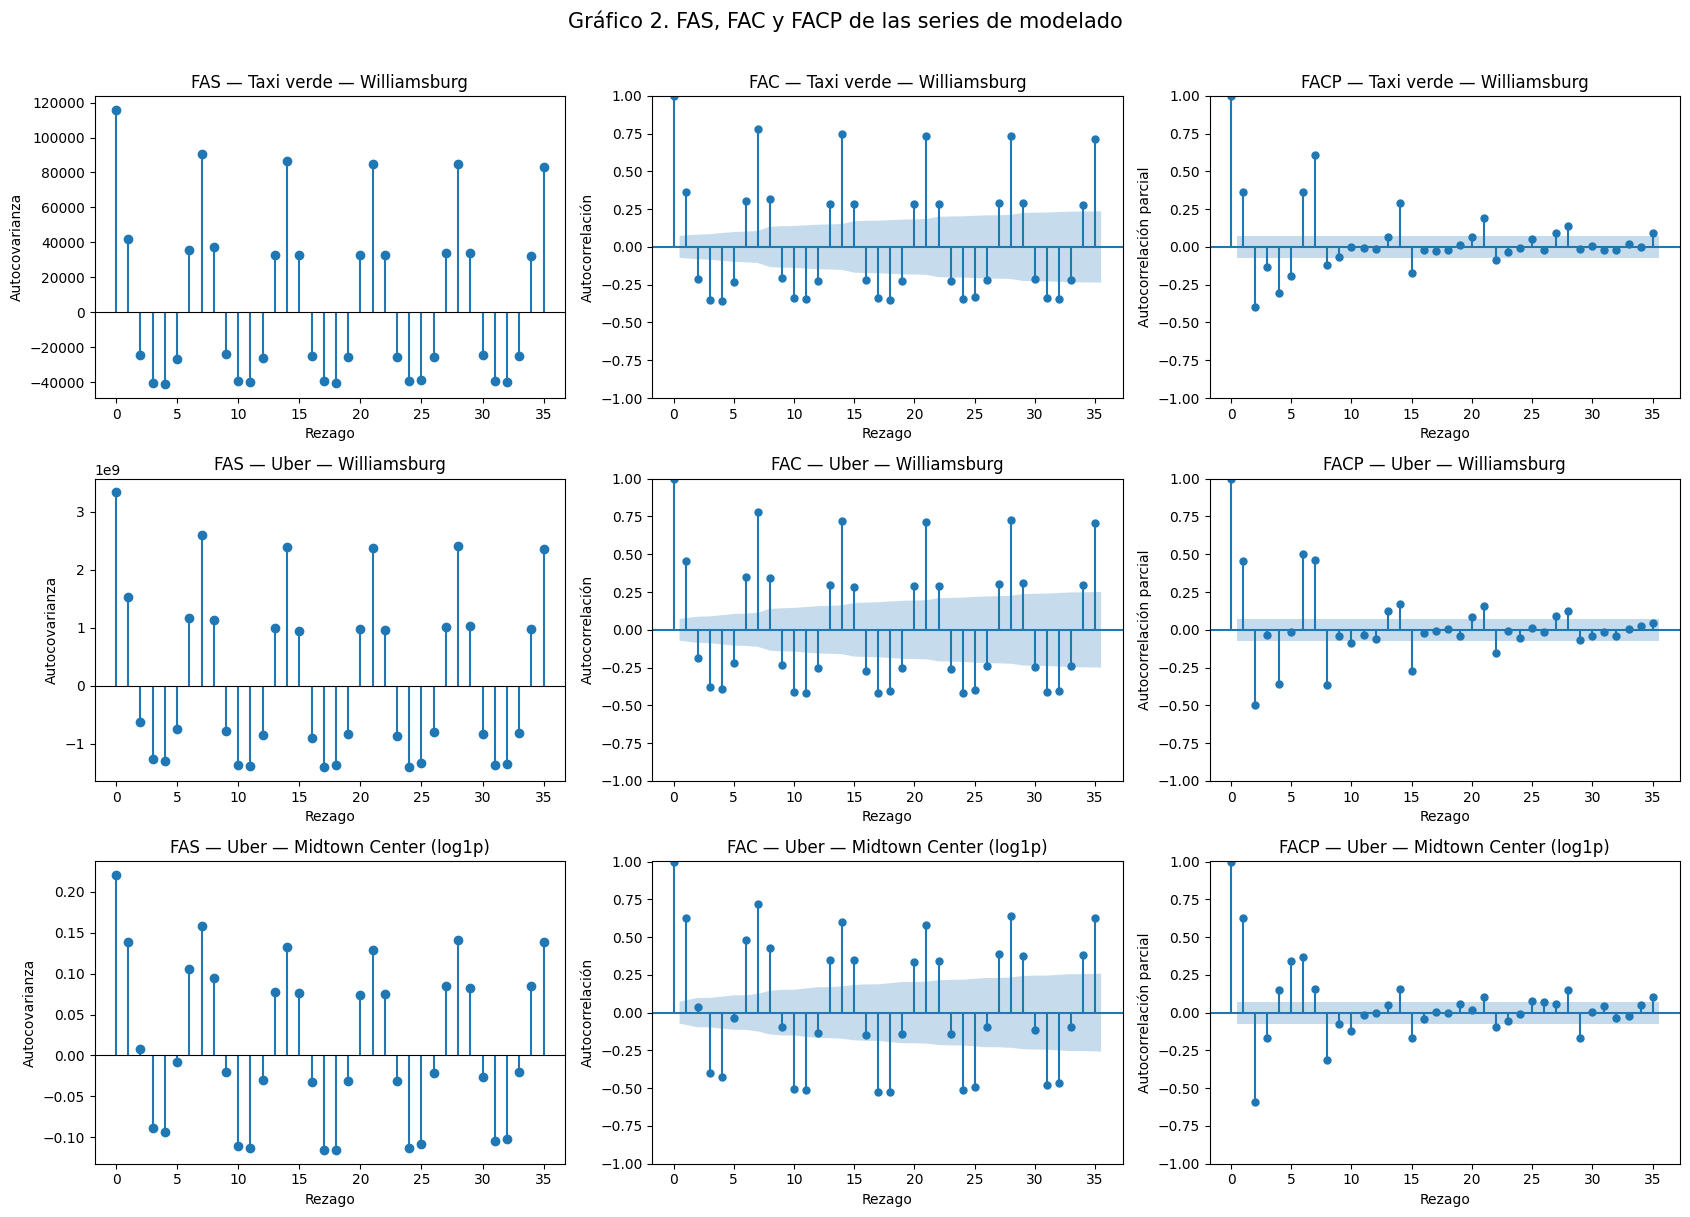

In [14]:
MAX_LAGS = 35


def graficar_dependencia_temporal(datos, columnas, titulo_general, max_lags=MAX_LAGS):
    """Grafica FAS, FAC y FACP (una fila por serie) para las columnas indicadas."""
    fig, axes = plt.subplots(nrows=len(columnas), ncols=3, figsize=(17, 4 * len(columnas)))

    for fila, (columna, titulo) in enumerate(columnas.items()):
        serie = datos[columna].dropna()

        # FAS (función de autocovarianza muestral)
        autocovarianzas = acovf(serie, adjusted=False, demean=True, fft=True, nlag=max_lags)
        axes[fila, 0].stem(range(len(autocovarianzas)), autocovarianzas, basefmt=' ')
        axes[fila, 0].axhline(0, color='black', linewidth=0.8)
        axes[fila, 0].set_title(f'FAS — {titulo}')
        axes[fila, 0].set_xlabel('Rezago')
        axes[fila, 0].set_ylabel('Autocovarianza')

        # FAC
        plot_acf(serie, lags=max_lags, alpha=0.05, zero=True, ax=axes[fila, 1])
        axes[fila, 1].set_title(f'FAC — {titulo}')
        axes[fila, 1].set_xlabel('Rezago')
        axes[fila, 1].set_ylabel('Autocorrelación')

        # FACP
        plot_pacf(serie, lags=max_lags, alpha=0.05, zero=True, method='ywm', ax=axes[fila, 2])
        axes[fila, 2].set_title(f'FACP — {titulo}')
        axes[fila, 2].set_xlabel('Rezago')
        axes[fila, 2].set_ylabel('Autocorrelación parcial')

    fig.suptitle(titulo_general, fontsize=15, y=1.01)
    plt.tight_layout()
    plt.show()


graficar_dependencia_temporal(
    datos=df_modelo,
    columnas=COLUMNAS_MODELO,
    titulo_general='Gráfico 2. FAS, FAC y FACP de las series de modelado',
)

## 6. Variables exógenas de calendario

Se construyen dos conjuntos de variables a partir del índice de fechas:

- **`exog_calendario`**: variables de calendario completas (día del mes, día de la semana, semana del
  año, mes, trimestre, año, feriado). Se usan como *features* para los modelos de Machine Learning,
  que pueden manejar relaciones no lineales entre esas variables y el target.
- **Bloques exógenos para SARIMAX**: solo el indicador de feriados y las dummies de año. El resto de
  las variables de calendario no se pasan a SARIMAX porque como enteros impondrían una relación
  lineal sin sentido (diciembre no es "doce veces" enero) y porque mes / trimestre / semana se
  solapan con la estacionalidad semanal que ya capturan los términos (P, D, Q, s=7).

Las dummies de año se construyen con `drop_first=True` para evitar colinealidad perfecta con la
constante del modelo: el año 2024 queda como categoría base.

In [15]:
ANIOS = range(df_modelo.index.year.min(), df_modelo.index.year.max() + 1)
feriados_us_ny = holidays.country_holidays('US', subdiv='NY', years=list(ANIOS))

exog_calendario = pd.DataFrame(index=df_modelo.index)
exog_calendario['dayofmonth'] = df_modelo.index.day
exog_calendario['dayofweek'] = df_modelo.index.dayofweek
exog_calendario['weekofyear'] = df_modelo.index.isocalendar().week.astype(int).values
exog_calendario['month'] = df_modelo.index.month
exog_calendario['quarter'] = df_modelo.index.quarter
exog_calendario['year'] = df_modelo.index.year
exog_calendario['holiday'] = [int(fecha in feriados_us_ny) for fecha in df_modelo.index.date]

# Dummies de año (2024 = categoría base)
dummies_anio = pd.get_dummies(df_modelo.index.year.astype(str), prefix='anio', drop_first=True).astype(int)
dummies_anio.index = df_modelo.index
COLS_ANIO = list(dummies_anio.columns)

# Tabla de exógenas disponible para SARIMAX
exog_sarimax = pd.concat([exog_calendario[['holiday']], dummies_anio], axis=1)

# Variantes que se comparan en el grid search
EXOG_VARIANTES = {
    'sin_exogenas': [],
    'feriados': ['holiday'],
    'anio': COLS_ANIO,
    'feriados_anio': ['holiday'] + COLS_ANIO,
}

print(f'Feriados US/NY en el período ({FECHA_INICIO} a {FECHA_FIN}): {exog_calendario["holiday"].sum()} días')
print(f'Dummies de año: {COLS_ANIO} (base: {min(ANIOS)})')
print(f'Variantes exógenas a comparar: {list(EXOG_VARIANTES)}')
exog_sarimax.head()

Feriados US/NY en el período (2024-06-01 a 2026-05-31): 28 días
Dummies de año: ['anio_2025', 'anio_2026'] (base: 2024)
Variantes exógenas a comparar: ['sin_exogenas', 'feriados', 'anio', 'feriados_anio']


,holiday,anio_2025,anio_2026
fecha,,,
2024-06-01,0,0,0
2024-06-02,0,0,0
2024-06-03,0,0,0
2024-06-04,0,0,0
2024-06-05,0,0,0


## 7. Variables autorregresivas (rezagos y estadísticos móviles)

Este bloque prepara la matriz de *features* para los modelos de Machine Learning. Los estadísticos
móviles se calculan sobre la serie desplazada un día, de modo que en *t* solo resuman información
hasta *t−1* (sin *leakage*).

In [16]:
LAGS = [1, 2, 7, 14, 21, 28, 30, 35]
VENTANAS_ROLLING = [7, 14, 28, 35]


def agregar_features_autorregresivas(serie, lags=LAGS, ventanas=VENTANAS_ROLLING):
    """Construye rezagos y estadísticos móviles (media, desvío) de `serie`."""
    feats = pd.DataFrame(index=serie.index)

    for lag in lags:
        feats[f'lag_{lag}'] = serie.shift(lag)

    serie_desplazada = serie.shift(1)
    for ventana in ventanas:
        rolling = serie_desplazada.rolling(ventana)
        feats[f'rolling_mean_{ventana}'] = rolling.mean()
        feats[f'rolling_std_{ventana}'] = rolling.std()

    return feats


features_por_serie = {}

for serie in SERIES:
    col = columna_modelo(serie)
    feats_autorregresivas = agregar_features_autorregresivas(df_modelo[col])
    features_completas = exog_calendario.join(feats_autorregresivas)
    features_completas['target'] = df_modelo[col]
    features_por_serie[serie] = features_completas

    n_features = features_completas.shape[1] - 1
    n_nan = features_completas.drop(columns='target').isna().any(axis=1).sum()
    print(f'{serie:28s}: {features_completas.shape[0]} filas, {n_features} features '
          f'(+ target) | filas con algún NaN: {n_nan}')

features_por_serie['uber_midtown'].dropna().head()

taxi_verde_williamsburg     : 730 filas, 23 features (+ target) | filas con algún NaN: 35
uber_williamsburg           : 730 filas, 23 features (+ target) | filas con algún NaN: 35
uber_midtown                : 730 filas, 23 features (+ target) | filas con algún NaN: 35


,dayofmonth,dayofweek,weekofyear,month,quarter,year,holiday,lag_1,lag_2,lag_7,...,lag_35,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,rolling_mean_28,rolling_std_28,rolling_mean_35,rolling_std_35,target
fecha,,,,,,,,,,,,,,,,,,,,,
2024-07-06,6,5,27,7,3,2024,0,11.880252,11.447113,11.963767,...,11.996931,12.004201,0.326048,12.308611,0.507195,12.406047,0.485056,12.437309,0.497784,11.871217
2024-07-07,7,6,27,7,3,2024,0,11.871217,11.880252,11.872747,...,11.641280,11.990979,0.329815,12.293747,0.517379,12.398744,0.491707,12.433717,0.501495,11.838551
2024-07-08,8,0,28,7,3,2024,0,11.838551,11.871217,12.290677,...,12.544238,11.986094,0.332104,12.284399,0.524818,12.405530,0.482190,12.439353,0.493369,12.475636
2024-07-09,9,1,28,7,3,2024,0,12.475636,11.838551,12.446668,...,12.920301,12.012517,0.366003,12.274829,0.519628,12.400040,0.480419,12.437393,0.493076,12.819589
2024-07-10,10,2,28,7,3,2024,0,12.819589,12.475636,12.128184,...,13.076568,12.065791,0.455844,12.263699,0.504929,12.396863,0.477216,12.434516,0.490462,12.912920


## 8. Benchmark estadístico: SARIMAX

### 8.1. Partición train / test

La partición usa meses calendario completos: el test es el último mes de la serie (mayo de 2026) y el
train es todo lo anterior. La selección de hiperparámetros se hace **exclusivamente sobre train**
(por AIC / BIC); el test no interviene en ningún momento de esta etapa.

In [17]:
def dividir_train_test(serie):
    """Divide la serie en train / test usando meses calendario completos:
    - test: último mes calendario presente en la serie (mayo de 2026)
    - train: todo lo anterior a ese mes
    """
    serie = serie.dropna()
    periodos = serie.index.to_period('M')
    ultimo_mes = periodos.max()

    test = serie[periodos == ultimo_mes]
    train = serie[periodos < ultimo_mes]

    return train, test


splits = {}
for serie in SERIES:
    train, test = dividir_train_test(df_modelo[columna_modelo(serie)])
    splits[serie] = (train, test)
    print(f'{serie:28s}: train {train.index.min().date()} a {train.index.max().date()} '
          f'({len(train)} días) | test {test.index.min().date()} a {test.index.max().date()} '
          f'({len(test)} días)')

taxi_verde_williamsburg     : train 2024-06-01 a 2026-04-30 (699 días) | test 2026-05-01 a 2026-05-31 (31 días)
uber_williamsburg           : train 2024-06-01 a 2026-04-30 (699 días) | test 2026-05-01 a 2026-05-31 (31 días)
uber_midtown                : train 2024-06-01 a 2026-04-30 (699 días) | test 2026-05-01 a 2026-05-31 (31 días)


### 8.2. Espacio de búsqueda

Los rangos por serie salen del análisis del TP1 (FAC / FACP y resultados del grid search previo).
Se comparan dos familias:

- **SARIMAX**: usa los rangos estacionales (P, D, Q) de cada serie.
- **ARIMAX**: caso particular sin componente estacional (P = D = Q = 0).

Una aclaración importante sobre la comparabilidad del AIC: el criterio solo se puede comparar entre
modelos ajustados sobre **la misma variable dependiente y la misma muestra**. Por eso *d* y *D* se
fijan en 0 en todas las familias, incluida ARIMAX (en la versión anterior del script ARIMAX tenía
`d=(0, 1)`, lo que habría mezclado en un mismo ranking modelos sobre la serie en nivel y sobre la
serie diferenciada). Con d = D = 0, en cambio, el AIC **sí** es comparable entre variantes con y sin
exógenas, que es justamente lo que permite responder si conviene incorporarlas.

In [18]:
configuracion_series = {
    'taxi_verde_williamsburg': dict(p=(0, 3), d=(0, 0), q=(0, 2), P=(0, 2), D=(0, 0), Q=(0, 2)),
    'uber_williamsburg':       dict(p=(0, 3), d=(0, 0), q=(0, 2), P=(0, 2), D=(0, 0), Q=(0, 2)),
    'uber_midtown':            dict(p=(0, 3), d=(0, 0), q=(0, 2), P=(0, 2), D=(0, 0), Q=(0, 2)),
}

# SARIMAX toma los rangos estacionales de configuracion_series.
# ARIMAX los anula (P = D = Q = 0) y amplía p y q.
FAMILIAS = {
    'SARIMAX': None,
    'ARIMAX': dict(p=(0, 3), d=(0, 0), q=(0, 3), P=(0, 0), D=(0, 0), Q=(0, 0)),
}


def rangos_de(serie, familia):
    """Devuelve los rangos (p, d, q, P, D, Q) para una serie y una familia."""
    base = dict(configuracion_series[serie])
    override = FAMILIAS[familia]
    if override is not None:
        base.update(override)
    return base


for serie in SERIES:
    for familia in FAMILIAS:
        r = rangos_de(serie, familia)
        n_comb = int(np.prod([r[k][1] - r[k][0] + 1 for k in ('p', 'd', 'q', 'P', 'D', 'Q')]))
        print(f'{serie:28s} {familia:8s}: {n_comb:4d} combinaciones x {len(EXOG_VARIANTES)} variantes '
              f'exógenas = {n_comb * len(EXOG_VARIANTES):5d} ajustes')

taxi_verde_williamsburg      SARIMAX :  108 combinaciones x 4 variantes exógenas =   432 ajustes
taxi_verde_williamsburg      ARIMAX  :   16 combinaciones x 4 variantes exógenas =    64 ajustes
uber_williamsburg            SARIMAX :  108 combinaciones x 4 variantes exógenas =   432 ajustes
uber_williamsburg            ARIMAX  :   16 combinaciones x 4 variantes exógenas =    64 ajustes
uber_midtown                 SARIMAX :  108 combinaciones x 4 variantes exógenas =   432 ajustes
uber_midtown                 ARIMAX  :   16 combinaciones x 4 variantes exógenas =    64 ajustes


### 8.3. Grid search con caché

La búsqueda es exhaustiva sobre el producto cartesiano de los rangos. Para no tener que rehacer el
trabajo, los resultados se cachean en disco (Google Drive) con estas características:

- **Un archivo por combinación de (serie, familia, variante exógena)**, con un hash en el nombre que
  resume los rangos, el período estacional, las columnas exógenas y las fechas del train. Si cambiás
  cualquiera de esas cosas, el hash cambia y esa búsqueda se recalcula; el resto queda intacto.
- **Guardado incremental**: el caché se persiste cada `guardar_cada` modelos ajustados, no al final.
  Si se corta Colab a mitad de camino, al volver a ejecutar la celda se retoma exactamente donde
  quedó, ajustando solo las combinaciones pendientes.
- **Las combinaciones que fallan también se cachean**, con su estado de error, para no reintentarlas
  en cada corrida.
- `FORZAR_RECALCULO_GRID = True` ignora el caché y vuelve a ajustar todo desde cero.

In [19]:
CACHE_GRID_DIR = CACHE_DIR / 'gridsearch'
CACHE_GRID_DIR.mkdir(parents=True, exist_ok=True)

FORZAR_RECALCULO_GRID = False
VERSION_GRID = 'v1'  # cambiar si se modifica la lógica de ajuste (invalida todo el caché)


def _firma_busqueda(serie, familia, variante, rangos, s, y_train, cols_exog):
    """Diccionario que identifica unívocamente una búsqueda."""
    return {
        'version': VERSION_GRID,
        'serie': serie,
        'familia': familia,
        'variante': variante,
        'rangos': {k: list(v) for k, v in sorted(rangos.items())},
        's': s,
        'cols_exog': sorted(cols_exog),
        'n_train': int(len(y_train)),
        'train_inicio': str(y_train.index.min().date()),
        'train_fin': str(y_train.index.max().date()),
        'transformacion': SERIES[serie]['transformacion'],
    }


def _ruta_cache(firma):
    texto = json.dumps(firma, sort_keys=True, ensure_ascii=False)
    hash_corto = hashlib.md5(texto.encode('utf-8')).hexdigest()[:10]
    nombre = f'{firma["serie"]}__{firma["familia"]}__{firma["variante"]}__{hash_corto}.pkl'
    return CACHE_GRID_DIR / nombre


def _guardar_cache(ruta, contenido):
    """Escritura en archivo temporal + reemplazo, para no dejar un pickle a medio escribir
    si el entorno se corta justo durante el guardado."""
    ruta_tmp = ruta.with_suffix('.tmp')
    with open(ruta_tmp, 'wb') as f:
        pickle.dump(contenido, f)
    ruta_tmp.replace(ruta)


def grid_search_sarimax(serie, familia, variante, y_train, exog_train=None,
                        s=PERIODO_ESTACIONAL, criterio='AIC',
                        forzar=FORZAR_RECALCULO_GRID, guardar_cada=10, verbose=True):
    """Búsqueda exhaustiva de hiperparámetros SARIMAX por grid search, con caché en disco.

    Ajusta un modelo por cada combinación (p,d,q)(P,D,Q,s) de los rangos definidos para
    esa serie y familia, y lo evalúa por AIC / BIC sobre train. El test no interviene.

    Devuelve un DataFrame con los modelos que ajustaron correctamente, ordenado por `criterio`.
    """
    rangos = rangos_de(serie, familia)
    cols_exog = list(exog_train.columns) if exog_train is not None else []

    firma = _firma_busqueda(serie, familia, variante, rangos, s, y_train, cols_exog)
    ruta = _ruta_cache(firma)

    # --- Lectura del caché ---
    evaluados = {}
    if ruta.exists() and not forzar:
        with open(ruta, 'rb') as f:
            cache = pickle.load(f)
        if cache.get('firma') == firma:
            evaluados = cache['resultados']

    combinaciones = list(itertools.product(*[
        range(rangos[k][0], rangos[k][1] + 1) for k in ('p', 'd', 'q', 'P', 'D', 'Q')
    ]))
    pendientes = [c for c in combinaciones if c not in evaluados]

    if verbose:
        print(f'  {serie} | {familia} | {variante}: {len(combinaciones)} combinaciones '
              f'({len(evaluados)} en caché, {len(pendientes)} pendientes)')

    # --- Ajuste de las combinaciones pendientes ---
    for i, combo in enumerate(pendientes, start=1):
        pp, dd, qq, PP, DD, QQ = combo
        order = (pp, dd, qq)
        seasonal_order = (PP, DD, QQ, s)

        try:
            modelo = SARIMAX(
                y_train, exog=exog_train, order=order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False,
            )
            ajuste = modelo.fit(disp=False)
            evaluados[combo] = {
                'estado': 'ok',
                'order': order,
                'seasonal_order': seasonal_order,
                'AIC': float(ajuste.aic),
                'BIC': float(ajuste.bic),
                'LLF': float(ajuste.llf),
                'convergio': bool(ajuste.mle_retvals.get('converged', True)),
                'n_params': int(len(ajuste.params)),
            }
        except Exception as error:
            evaluados[combo] = {
                'estado': 'error',
                'order': order,
                'seasonal_order': seasonal_order,
                'mensaje': f'{type(error).__name__}: {error}',
            }

        if i % guardar_cada == 0 or i == len(pendientes):
            _guardar_cache(ruta, {'firma': firma, 'resultados': evaluados})
            if verbose:
                print(f'    {i}/{len(pendientes)} ajustadas (caché guardado)')

    # --- Armado del DataFrame de salida ---
    validos = [r for r in evaluados.values() if r['estado'] == 'ok']
    n_errores = len(evaluados) - len(validos)

    if verbose:
        print(f'    Completado: {len(validos)} modelos válidos, {n_errores} con error.')

    if not validos:
        return pd.DataFrame(columns=['order', 'seasonal_order', 'AIC', 'BIC', 'LLF',
                                     'convergio', 'n_params'])

    return (
        pd.DataFrame(validos)
        .drop(columns='estado')
        .sort_values(by=criterio)
        .reset_index(drop=True)
    )

### 8.4. Ejecución de la búsqueda

Se recorren las tres series, las dos familias y las cuatro variantes exógenas
(`sin_exogenas`, `feriados`, `anio`, `feriados_anio`). La primera corrida completa es larga; las
siguientes se resuelven casi por completo desde el caché.

In [ ]:
resultados_grid = {}   # (serie, familia, variante) -> DataFrame completo, ordenado por AIC
mejores = []           # una fila por combinación, con el mejor modelo de cada búsqueda

for serie in SERIES:
    y_train, _ = splits[serie]

    for familia in FAMILIAS:
        for variante, cols in EXOG_VARIANTES.items():
            exog_train = (exog_sarimax.loc[y_train.index, cols].astype(float)
                          if cols else None)

            res = grid_search_sarimax(
                serie=serie, familia=familia, variante=variante,
                y_train=y_train, exog_train=exog_train,
            )
            resultados_grid[(serie, familia, variante)] = res

            if not res.empty:
                mejor = res.iloc[0]
                mejores.append({
                    'serie': serie,
                    'Serie': SERIES[serie]['etiqueta'],
                    'Familia': familia,
                    'Variante exógena': variante,
                    'k exógenas': len(cols),
                    'order': str(mejor['order']),
                    'seasonal_order': str(mejor['seasonal_order']),
                    'AIC': mejor['AIC'],
                    'BIC': mejor['BIC'],
                    # se conservan las tuplas para poder reconstruir el modelo más adelante
                    'order_t': mejor['order'],
                    'seasonal_order_t': mejor['seasonal_order'],
                })

tabla_mejores = pd.DataFrame(mejores)
print(f'\nBúsquedas completadas: {len(resultados_grid)}')
tabla_mejores.drop(columns=['serie', 'order_t', 'seasonal_order_t'])

  taxi_verde_williamsburg | SARIMAX | sin_exogenas: 108 combinaciones (0 en caché, 108 pendientes)
    10/108 ajustadas (caché guardado)
    20/108 ajustadas (caché guardado)
    30/108 ajustadas (caché guardado)
    40/108 ajustadas (caché guardado)
    50/108 ajustadas (caché guardado)
    60/108 ajustadas (caché guardado)
    70/108 ajustadas (caché guardado)
    80/108 ajustadas (caché guardado)
    90/108 ajustadas (caché guardado)
    100/108 ajustadas (caché guardado)
    108/108 ajustadas (caché guardado)
    Completado: 108 modelos válidos, 0 con error.
  taxi_verde_williamsburg | SARIMAX | feriados: 108 combinaciones (0 en caché, 108 pendientes)
    10/108 ajustadas (caché guardado)
    20/108 ajustadas (caché guardado)
    30/108 ajustadas (caché guardado)
    40/108 ajustadas (caché guardado)
    50/108 ajustadas (caché guardado)
    60/108 ajustadas (caché guardado)
    70/108 ajustadas (caché guardado)
    80/108 ajustadas (caché guardado)
    90/108 ajustadas (caché guar

### 8.5. ¿Conviene incorporar las variables exógenas?

La comparación se hace dentro de cada par (serie, familia): se toma el mejor modelo sin exógenas
como referencia y se calcula el ΔAIC de cada variante contra él. Un ΔAIC **negativo** indica que
la variante con exógenas mejora el ajuste.

Como criterio de lectura habitual, una diferencia de menos de 2 puntos de AIC se considera evidencia
débil (los modelos son prácticamente equivalentes y conviene quedarse con el más parsimonioso, o sea
el que no incorpora exógenas); entre 2 y 10 puntos, evidencia moderada; más de 10 puntos, evidencia
fuerte a favor del modelo con menor AIC.

In [ ]:
tabla_comparacion = tabla_mejores.copy()

# Referencia: el mejor modelo sin exógenas de cada par (serie, familia)
referencia = (
    tabla_comparacion[tabla_comparacion['Variante exógena'] == 'sin_exogenas']
    .set_index(['serie', 'Familia'])[['AIC', 'BIC']]
    .rename(columns={'AIC': 'AIC_ref', 'BIC': 'BIC_ref'})
)

tabla_comparacion = tabla_comparacion.join(referencia, on=['serie', 'Familia'])
tabla_comparacion['Δ AIC'] = tabla_comparacion['AIC'] - tabla_comparacion['AIC_ref']
tabla_comparacion['Δ BIC'] = tabla_comparacion['BIC'] - tabla_comparacion['BIC_ref']


def leer_delta(delta):
    """Lectura del ΔAIC respecto del mejor modelo sin exógenas."""
    if delta <= -10:
        return 'Mejora fuerte'
    if delta <= -2:
        return 'Mejora moderada'
    if delta < 2:
        return 'Equivalente (elegir el más parsimonioso)'
    if delta < 10:
        return 'Empeora levemente'
    return 'Empeora'


tabla_comparacion['Evidencia'] = tabla_comparacion['Δ AIC'].apply(leer_delta)
tabla_comparacion.loc[tabla_comparacion['Variante exógena'] == 'sin_exogenas', 'Evidencia'] = '— (referencia)'

tabla_comparacion = (
    tabla_comparacion
    .sort_values(['Serie', 'Familia', 'AIC'])
    .drop(columns=['serie', 'AIC_ref', 'BIC_ref', 'order_t', 'seasonal_order_t'])
    .reset_index(drop=True)
)

(
    GT(tabla_comparacion, groupname_col='Serie')
    .tab_header(
        title='Tabla 4. Grid search SARIMAX / ARIMAX: comparación de variantes exógenas',
        subtitle='Mejor modelo por variante (AIC sobre train). Δ calculado contra el mejor modelo sin exógenas de cada familia.'
    )
    .fmt_number(columns=['AIC', 'BIC', 'Δ AIC', 'Δ BIC'], decimals=2)
    .cols_label(**{
        'Variante exógena': md('Variante<br>exógena'),
        'k exógenas': md('k<br>exógenas'),
        'order': md('(p,d,q)'),
        'seasonal_order': md('(P,D,Q,s)'),
    })
    .tab_style(style=style.text(weight='bold'), locations=loc.body(columns='Familia'))
)

### 8.6. Modelo elegido por serie

Se selecciona, para cada serie, el modelo con menor AIC entre todas las familias y variantes. Como
todos los modelos comparten la misma variable dependiente y la misma muestra de train
(d = D = 0 en todas las familias), el AIC es directamente comparable entre ellos.

In [ ]:
seleccion = tabla_mejores.loc[tabla_mejores.groupby('serie')['AIC'].idxmin()].reset_index(drop=True)

MODELOS_ELEGIDOS = {}
for _, fila in seleccion.iterrows():
    serie = fila['serie']
    MODELOS_ELEGIDOS[serie] = {
        'familia': fila['Familia'],
        'variante': fila['Variante exógena'],
        'cols_exog': EXOG_VARIANTES[fila['Variante exógena']],
        'order': fila['order_t'],
        'seasonal_order': fila['seasonal_order_t'],
        'AIC': fila['AIC'],
        'BIC': fila['BIC'],
    }
    print(f'{serie:28s}: {fila["Familia"]} {fila["order"]}{fila["seasonal_order"]} '
          f'| exógenas: {fila["Variante exógena"]} | AIC = {fila["AIC"]:.2f}')

seleccion.drop(columns=['order_t', 'seasonal_order_t'])

In [ ]:
# ---------------------------------------------------------------------------
# Especificación elegida a mano para cada serie
# ---------------------------------------------------------------------------
# Claves obligatorias de cada entrada:
#   'order'          : (p, d, q)
#   'seasonal_order' : (P, D, Q, s)  -> s debe ser PERIODO_ESTACIONAL (7)
#   'variante'       : clave de EXOG_VARIANTES
#                      ('sin_exogenas', 'feriados', 'anio', 'feriados_anio')
#   'comentario'     : justificación breve (queda documentada en la tabla comparativa)
#
# >>> EDITAR ACÁ los órdenes definitivos de cada serie. <<<
PARAMETROS_MANUALES = {
    'taxi_verde_williamsburg': {
        'order': (0, 0, 2),
        'seasonal_order': (1, 0, 2, PERIODO_ESTACIONAL),
        'variante': 'feriados',
    },
    'uber_williamsburg': {
        'order': (3, 0, 2),
        'seasonal_order': (2, 0, 2, PERIODO_ESTACIONAL),
        'variante': 'sin_exogenas',
    },
    'uber_midtown': {
        'order': (1, 0, 0),
        'seasonal_order': (2, 0, 3, PERIODO_ESTACIONAL),
        'variante': 'feriados',
    },
}

# True  -> se usan los órdenes de PARAMETROS_MANUALES
# False -> se usan los que eligió el grid search (MODELOS_ELEGIDOS, sección 8.6)
USAR_PARAMETROS_MANUALES = True


def _validar_parametros_manuales(parametros=PARAMETROS_MANUALES):
    """Chequea las claves del diccionario antes de ajustar nada.

    Evita el error típico de escribir mal el nombre de una serie o de una variante
    exógena y enterarse recién cuando falla el ajuste.
    """
    for serie, cfg in parametros.items():
        assert serie in SERIES, f'{serie!r} no es una serie válida: {list(SERIES)}'

        faltantes = {'order', 'seasonal_order'} - set(cfg)
        assert not faltantes, f'{serie}: faltan las claves {sorted(faltantes)}'

        assert len(cfg['order']) == 3, f'{serie}: order debe ser (p, d, q)'
        assert len(cfg['seasonal_order']) == 4, f'{serie}: seasonal_order debe ser (P, D, Q, s)'
        assert cfg['seasonal_order'][3] == PERIODO_ESTACIONAL, \
            f'{serie}: el período estacional debe ser {PERIODO_ESTACIONAL}'

        variante = cfg.get('variante', 'sin_exogenas')
        assert variante in EXOG_VARIANTES, \
            f'{serie}: variante {variante!r} desconocida; opciones: {list(EXOG_VARIANTES)}'

    return True


def construir_modelos_finales(usar_manuales=USAR_PARAMETROS_MANUALES,
                              parametros=PARAMETROS_MANUALES):
    """Devuelve {serie: especificación} combinando los parámetros manuales y el grid search.

    Una serie que no aparezca en `parametros` cae automáticamente en lo que haya
    elegido el grid search, así se pueden fijar a mano solo algunas series.
    """
    _validar_parametros_manuales(parametros)
    elegidos_grid = globals().get('MODELOS_ELEGIDOS', {})

    finales = {}
    for serie in SERIES:
        usar_manual = usar_manuales and serie in parametros

        if usar_manual:
            cfg = parametros[serie]
            variante = cfg.get('variante', 'sin_exogenas')
            seasonal_order = tuple(cfg['seasonal_order'])
            # Si (P, D, Q) = (0, 0, 0) el modelo es, en los hechos, un ARIMAX.
            familia = 'ARIMAX' if not any(seasonal_order[:3]) else 'SARIMAX'

            finales[serie] = {
                'origen': 'manual',
                'familia': familia,
                'variante': variante,
                'cols_exog': EXOG_VARIANTES[variante],
                'order': tuple(cfg['order']),
                'seasonal_order': seasonal_order,
                'comentario': cfg.get('comentario', ''),
            }
        else:
            assert serie in elegidos_grid, (
                f'{serie}: no está en PARAMETROS_MANUALES y tampoco hay resultado del grid search. '
                'Ejecutá la sección 8.6 o agregá la serie al diccionario manual.'
            )
            base = elegidos_grid[serie]
            finales[serie] = {
                'origen': 'grid search',
                'familia': base['familia'],
                'variante': base['variante'],
                'cols_exog': base['cols_exog'],
                'order': tuple(base['order']),
                'seasonal_order': tuple(base['seasonal_order']),
                'comentario': f'Menor AIC del grid search (AIC = {base["AIC"]:.2f}).',
            }

    return finales


MODELOS_FINALES = construir_modelos_finales()

# Tabla comparativa: qué proponía el grid search vs. qué se usa finalmente.
_elegidos_grid = globals().get('MODELOS_ELEGIDOS', {})
tabla_especificacion = pd.DataFrame([
    {
        'Serie': SERIES[serie]['etiqueta'],
        'Origen': cfg['origen'],
        'Familia': cfg['familia'],
        'Modelo final': f'{cfg["order"]}{cfg["seasonal_order"]}',
        'Exógenas': cfg['variante'],
        'Grid search proponía': (
            f'{tuple(_elegidos_grid[serie]["order"])}{tuple(_elegidos_grid[serie]["seasonal_order"])}'
            f' | {_elegidos_grid[serie]["variante"]}'
            if serie in _elegidos_grid else '—'
        ),
        'Comentario': cfg['comentario'],
    }
    for serie, cfg in MODELOS_FINALES.items()
])

(
    GT(tabla_especificacion)
    .tab_header(
        title='Tabla 7. Especificación final de cada serie',
        subtitle=f'USAR_PARAMETROS_MANUALES = {USAR_PARAMETROS_MANUALES}'
    )
    .tab_style(style=style.text(weight='bold'), locations=loc.body(columns='Serie'))
    .tab_options(table_font_names='Arial')
)

In [ ]:
def ajustar_modelo_final(serie, cfg, verbose=True):
    """Ajusta sobre train la especificación indicada y devuelve el resultado de statsmodels."""
    y_train, _ = splits[serie]
    cols = cfg['cols_exog']
    exog_train = (exog_sarimax.loc[y_train.index, cols].astype(float) if cols else None)

    modelo = SARIMAX(
        y_train,
        exog=exog_train,
        order=cfg['order'],
        seasonal_order=cfg['seasonal_order'],
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    ajuste = modelo.fit(disp=False)

    if verbose:
        convergio = ajuste.mle_retvals.get('converged', True)
        print(f'{serie:28s}: {cfg["familia"]} {cfg["order"]}{cfg["seasonal_order"]} '
              f'| exógenas: {cfg["variante"]:14s} | AIC = {ajuste.aic:9.2f} '
              f'| BIC = {ajuste.bic:9.2f} | convergió: {convergio}')

    return ajuste


ajustes_finales = {serie: ajustar_modelo_final(serie, cfg)
                   for serie, cfg in MODELOS_FINALES.items()}

In [ ]:
# Ljung-Box no está entre los imports de la sección 1; si se prefiere, moverlo allá.
from statsmodels.stats.diagnostic import acorr_ljungbox

# Rezagos en los que se evalúa la prueba: múltiplos del período estacional (7 días).
LAGS_LJUNG_BOX = [1, 2, 3, 7, 14, 21, 28]
MAX_LAGS_RESIDUOS = 35


def _rezagos_componente(componente):
    """Lista de rezagos que incluye un componente del orden (p, q, P o Q).

    SARIMAX admite dos formas de escribirlo y esta función las unifica:
    - entero:          2       -> todos los rezagos hasta el 2  -> [1, 2]
    - lista de rezagos [1, 3]  -> solo esos rezagos             -> [1, 3]
    - máscara 0/1      [1,0,1] -> los rezagos marcados          -> [1, 3]
    """
    if isinstance(componente, (list, tuple, np.ndarray)):
        valores = list(componente)
        if not valores:
            return []
        # Una lista de solo ceros y unos se interpreta como máscara, igual que en statsmodels
        if set(np.unique(valores)) <= {0, 1}:
            return [i + 1 for i, v in enumerate(valores) if v]
        return [int(v) for v in valores]
    return list(range(1, int(componente) + 1))


def grados_libertad_arma(cfg):
    """Cantidad de parámetros ARMA estimados.

    Se cuentan los términos efectivamente incluidos, no el orden máximo: con
    seasonal_order=(2, 0, [1, 3], 7) son 2 + 2 = 4, no 2 + 3.
    """
    p, _, q = cfg['order']
    P, _, Q, _ = cfg['seasonal_order']
    return sum(len(_rezagos_componente(c)) for c in (p, q, P, Q))


def residuos_modelo(ajuste, cfg, descartar_iniciales=None):
    """Residuos del modelo, sin las primeras observaciones de la inicialización difusa.

    Por defecto se descarta un tramo del largo del rezago más profundo del modelo.
    """
    p, d, q = cfg['order']
    P, D, Q, s = cfg['seasonal_order']

    if descartar_iniciales is None:
        def profundidad(componente, factor=1):
            rezagos = _rezagos_componente(componente)
            return factor * max(rezagos) if rezagos else 0

        descartar_iniciales = max(
            profundidad(p), profundidad(q),
            profundidad(P, s), profundidad(Q, s),
            d + s * D,
        )

    resid = pd.Series(ajuste.resid, index=ajuste.data.row_labels)
    return resid.iloc[descartar_iniciales:].dropna()


# Residuos de las tres series, listos para graficar y para la prueba
residuos_finales = {
    serie: residuos_modelo(ajustes_finales[serie], MODELOS_FINALES[serie])
    for serie in MODELOS_FINALES
}

for serie, resid in residuos_finales.items():
    print(f'{serie:28s}: {len(resid)} residuos | media = {resid.mean():.4f} '
          f'| desvío = {resid.std():.4f}')

In [ ]:
def graficar_diagnostico_residuos(residuos_por_serie, max_lags=MAX_LAGS_RESIDUOS):
    """Una fila por serie: residuos en el tiempo, FAC y FACP con bandas al 95%."""
    n = len(residuos_por_serie)
    fig, axes = plt.subplots(nrows=n, ncols=3, figsize=(17, 4 * n))
    axes = np.atleast_2d(axes)

    for fila, (serie, resid) in enumerate(residuos_por_serie.items()):
        cfg = MODELOS_FINALES[serie]
        titulo = f'{SERIES[serie]["etiqueta"]} — {cfg["order"]}{cfg["seasonal_order"]}'

        # Residuos en el tiempo: se busca que oscilen alrededor de cero sin patrón visible.
        axes[fila, 0].plot(resid.index, resid.values, lw=0.9, color='#4C72B0')
        axes[fila, 0].axhline(0, color='black', lw=0.8)
        axes[fila, 0].set_title(f'Residuos — {titulo}', fontsize=10)
        axes[fila, 0].set_xlabel('Fecha')
        axes[fila, 0].set_ylabel('Residuo')

        # FAC de los residuos (zero=False: el rezago 0 vale 1 por construcción y no aporta)
        plot_acf(resid, lags=max_lags, alpha=0.05, zero=False, ax=axes[fila, 1])
        axes[fila, 1].set_title(f'FAC de los residuos — {SERIES[serie]["etiqueta"]}', fontsize=10)
        axes[fila, 1].set_xlabel('Rezago')
        axes[fila, 1].set_ylabel('Autocorrelación')

        # FACP de los residuos
        plot_pacf(resid, lags=max_lags, alpha=0.05, zero=False, method='ywm', ax=axes[fila, 2])
        axes[fila, 2].set_title(f'FACP de los residuos — {SERIES[serie]["etiqueta"]}', fontsize=10)
        axes[fila, 2].set_xlabel('Rezago')
        axes[fila, 2].set_ylabel('Autocorrelación parcial')

        # Líneas de referencia en los múltiplos del período estacional
        for col in (1, 2):
            for k in range(PERIODO_ESTACIONAL, max_lags + 1, PERIODO_ESTACIONAL):
                axes[fila, col].axvline(k, color='#C44E52', lw=0.7, ls=':', alpha=0.7)

    fig.suptitle('Gráfico 1. Residuos, FAC y FACP de los modelos finales ', fontsize=12, y=1.0)
    fig.tight_layout()
    plt.show()


graficar_diagnostico_residuos(residuos_finales)

In [ ]:
def ljung_box_serie(serie, resid, cfg, lags=LAGS_LJUNG_BOX, alfa=0.05):
    """Aplica Ljung-Box a los residuos de una serie, corrigiendo por los parámetros ARMA."""
    gl_modelo = grados_libertad_arma(cfg)

    # Solo tienen sentido los rezagos que superan los grados de libertad consumidos.
    lags_validos = [h for h in lags if h > gl_modelo]
    if not lags_validos:
        return pd.DataFrame()

    prueba = acorr_ljungbox(resid, lags=lags_validos, model_df=gl_modelo, return_df=True)

    return pd.DataFrame({
        'Serie': SERIES[serie]['etiqueta'],
        'Modelo': f'{cfg["order"]}{cfg["seasonal_order"]}',
        'Rezago (h)': prueba.index,
        'Q (Ljung-Box)': prueba['lb_stat'].values,
        'gl': [h - gl_modelo for h in prueba.index],
        'p-valor': prueba['lb_pvalue'].values,
        'Conclusión': [
            'Se rechaza H₀: queda autocorrelación' if p < alfa
            else 'No se rechaza H₀: residuos ≈ ruido blanco'
            for p in prueba['lb_pvalue'].values
        ],
    })


tabla_ljung_box = pd.concat(
    [ljung_box_serie(serie, residuos_finales[serie], MODELOS_FINALES[serie])
     for serie in MODELOS_FINALES],
    ignore_index=True
)

(
    GT(tabla_ljung_box)
    .tab_header(
        title='Tabla 4. Prueba de Ljung-Box sobre los residuos de los modelos finales',
        subtitle='H₀: los residuos no están autocorrelacionados hasta el rezago h (α = 0,05)'
    )
    .fmt_number(columns=['Q (Ljung-Box)', 'p-valor'], decimals=4)
    .tab_style(style=style.text(weight='bold'), locations=loc.body(columns='Serie'))
    .tab_options(table_font_names='Arial')
)

## 9. Modelos de Machine Learning — LightGBM y XGBoost

Se incorporan dos ensambles de árboles de decisión con *gradient boosting* —**LightGBM** y
**XGBoost**— como segundo enfoque de pronóstico, entre el benchmark estadístico (SARIMAX) y la red
neuronal recurrente (LSTM).

A diferencia del SARIMAX, que modela la dependencia temporal a través de la estructura ARMA, estos
modelos la reciben **explícitamente como variables**: los rezagos y estadísticos móviles construidos
en la sección 7, más las variables de calendario de la sección 6. El modelo no "sabe" que los datos
son una serie de tiempo; aprende una función que mapea ese conjunto de *features* al valor del día.

El flujo replica deliberadamente el de la sección de LSTM, para que las métricas resulten
comparables entre los tres enfoques:

1. Verificación de requisitos previos.
2. Preparación de la matriz de *features* y partición train / test.
3. Definición de hiperparámetros y entrenamiento.
4. Validación cruzada temporal sobre **las mismas cinco ventanas** que usa el LSTM.
5. Evaluación en test (mayo 2026) — mismo horizonte que todos los demás modelos.
6. Diagnóstico de residuos.
7. Guardado de resultados para la tabla de comparación final.

**Diferencia metodológica central frente al LSTM:** como la matriz de *features* incluye rezagos de
orden 1 y 2, el pronóstico de los 31 días de test es necesariamente **recursivo** (cada día
predicho alimenta los rezagos del siguiente), mientras que el LSTM produce un pronóstico
**directo** del horizonte completo. Esa diferencia es intrínseca a los modelos y se documenta en el
análisis del error por día del horizonte.

### 9.2. Preparación de los datos

La matriz de *features* es la construida en la sección 7 (`features_por_serie`): variables de
calendario, rezagos de orden 1, 2, 7, 14, 21, 28, 30 y 35, y media y desvío móviles de 7, 14, 28 y
35 días calculados sobre la serie desplazada un día, de modo que en *t* solo resuman información
hasta *t−1*.

La constante `ESCALA_ML` define sobre qué escala se entrena:

- `'original'` — ingresos en dólares, **igual que el LSTM**. Es el valor por defecto, para que la
  comparación entre ambos enfoques no mezcle diferencias de escala con diferencias de modelo.
- `'modelo'` — aplica la transformación de la sección 4 (log1p en Uber — Midtown Center), igual que
  el SARIMAX, y destransforma antes de calcular las métricas.

En cualquiera de los dos casos **todas las métricas se reportan en dólares**, que es lo que hace
comparables los tres enfoques.

In [ ]:
import lightgbm as lgb
import xgboost as xgb

# 'original' = escala en dólares (igual que el LSTM) | 'modelo' = con la transformación de la sec. 4
ESCALA_ML = 'original'

# Variables de calendario que se usan como features. El LSTM usa un subconjunto
# (LSTM_FUTR_EXOG); para una comparación estricta puede reducirse a esa misma lista.
FEATURES_CALENDARIO = list(exog_calendario.columns)

HORIZONTE_TEST = 31                                  # días de mayo 2026, igual que LSTM y SARIMAX
FECHA_CORTE_TEST_ML = pd.Timestamp('2026-05-01')     # mismo criterio que dividir_train_test()


def construir_features_ml(serie, escala=ESCALA_ML):
    """Matriz de features + target de una serie, con las definiciones de las secciones 6 y 7.

    Se reconstruye en lugar de tomar `features_por_serie` directamente para poder
    alternar la escala de entrenamiento sin tocar el resto del notebook.
    """
    y = df[serie] if escala == 'original' else df_modelo[columna_modelo(serie)]

    feats = exog_calendario[FEATURES_CALENDARIO].join(agregar_features_autorregresivas(y))
    feats['target'] = y
    return feats


def destransformar_ml(serie, valores, escala=ESCALA_ML):
    """Lleva las predicciones a dólares. En escala 'original' no hace nada."""
    if escala == 'original':
        return valores
    return destransformar(serie, valores)


# ── Construcción de los datos por serie ───────────────────────────────────
datos_ml = {}
for serie, titulo in COLUMNAS_ORIGINALES.items():
    feats = construir_features_ml(serie)

    entrenamiento = feats[feats.index < FECHA_CORTE_TEST_ML].dropna()
    prueba = feats[feats.index >= FECHA_CORTE_TEST_ML]

    datos_ml[serie] = {
        'titulo': titulo,
        'X_train': entrenamiento.drop(columns='target'),
        'y_train': entrenamiento['target'],
        'fechas_test': prueba.index,
        'y_test': df.loc[prueba.index, serie],      # el real siempre en dólares
        'serie_completa': feats['target'],          # en la escala de entrenamiento
    }

    print(f"{titulo:28s}: train {entrenamiento.index.min().date()} → "
          f"{entrenamiento.index.max().date()} ({len(entrenamiento)} filas) | "
          f"test {prueba.index.min().date()} → {prueba.index.max().date()} ({len(prueba)} días)")

COLUMNAS_FEATURES = list(datos_ml[list(datos_ml)[0]]['X_train'].columns)
print(f"\nFeatures utilizadas ({len(COLUMNAS_FEATURES)}): {COLUMNAS_FEATURES}")
print(f"Escala de entrenamiento: {ESCALA_ML}")


# ── Ventanas del protocolo de evaluación ──────────────────────────────────
# Se definen acá porque las usan tanto la búsqueda de hiperparámetros (9.5)
# como la validación cruzada (9.6).
N_WINDOWS_CV = 5
STEP_SIZE_CV = 30


def ventanas_cv(ultimo_dia_train, h=HORIZONTE_TEST,
                n_windows=N_WINDOWS_CV, step_size=STEP_SIZE_CV):
    """Puntos de corte de la validación cruzada, con la convención de NeuralForecast.

    Cada ventana pronostica los días (cutoff, cutoff + h]. La última termina en el
    último día de train y las anteriores se desplazan `step_size` días hacia atrás.
    """
    cortes = [ultimo_dia_train - pd.Timedelta(days=h + i * step_size)
              for i in range(n_windows)]
    return sorted(cortes)


def verificar_ventanas(cortes):
    """Contrasta los puntos de corte con los que usó la CV del LSTM, si está en memoria."""
    if 'cv_df_lstm' not in globals():
        print('  [aviso] la CV del LSTM no está en memoria: no se puede verificar la coincidencia '
              'de ventanas. Ejecutá esta celda después de la sección de LSTM para comprobarlo.')
        return

    cortes_lstm = sorted(pd.to_datetime(pd.Series(cv_df_lstm['cutoff']).unique()))
    if [pd.Timestamp(c) for c in cortes] == [pd.Timestamp(c) for c in cortes_lstm]:
        print('  ✓ Los puntos de corte coinciden exactamente con los de la CV del LSTM.')
    else:
        print('  ⚠ Los puntos de corte NO coinciden con los del LSTM:')
        print(f'     ML  : {[str(pd.Timestamp(c).date()) for c in cortes]}')
        print(f'     LSTM: {[str(pd.Timestamp(c).date()) for c in cortes_lstm]}')
        print('     Las métricas de CV no serán estrictamente comparables hasta corregirlo.')


ULTIMO_DIA_TRAIN = datos_ml[list(datos_ml)[0]]['y_train'].index.max()
CORTES_CV = ventanas_cv(ULTIMO_DIA_TRAIN)

print(f'Ventanas de validación cruzada ({N_WINDOWS_CV} ventanas, step={STEP_SIZE_CV}, '
      f'h={HORIZONTE_TEST}):')
for corte in CORTES_CV:
    print(f'   corte {corte.date()} → pronostica {(corte + pd.Timedelta(days=1)).date()} '
          f'a {(corte + pd.Timedelta(days=HORIZONTE_TEST)).date()}')
verificar_ventanas(CORTES_CV)

### 9.3. Hiperparámetros

Los valores se eligen en función del tamaño del conjunto de entrenamiento (~665 filas utilizables
por serie), que es chico para ensambles de árboles. La configuración prioriza la regularización
sobre la capacidad:

| Parámetro | LightGBM | XGBoost | Justificación |
|-----------|----------|---------|---------------|
| `n_estimators` | 400 | 400 | Suficiente con tasa de aprendizaje baja |
| `learning_rate` | 0,05 | 0,05 | Compromiso entre convergencia y sobreajuste |
| profundidad | `num_leaves = 15` | `max_depth = 4` | Árboles poco profundos: pocas observaciones por hoja |
| `min_child_samples` / `min_child_weight` | 20 | 5 | Evita hojas con muy pocas observaciones |
| `subsample` | 0,8 | 0,8 | Submuestreo de filas (*bagging*) |
| `colsample_bytree` | 0,8 | 0,8 | Submuestreo de *features* en cada árbol |
| `reg_lambda` | 1,0 | 1,0 | Penalización L2 |
| `random_state` | 42 | 42 | Reproducibilidad, igual que la semilla del LSTM |

Estos valores funcionan como **línea de base**: son los que se usan mientras no se ejecute la
búsqueda de hiperparámetros de la sección 9.5, o si se decide desactivarla. Cuando esa búsqueda
corre, sus resultados reemplazan a estos valores para la serie y el modelo correspondientes.

In [ ]:
PARAMS_LGBM = dict(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=15,
    min_child_samples=20,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    verbose=-1,
)

PARAMS_XGB = dict(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0,
)

MODELOS_ML = ['LightGBM', 'XGBoost']

PARAMS_BASE = {'LightGBM': PARAMS_LGBM, 'XGBoost': PARAMS_XGB}

# Se completa en la sección 9.5 con los hiperparámetros que encuentre Optuna.
# Mientras esté vacío, todo el notebook usa los valores base de arriba.
MEJORES_PARAMS_ML = {}


def instanciar_modelo_ml(nombre, params=None):
    """Instancia nueva de un modelo. `params` reemplaza a los valores base."""
    configuracion = dict(PARAMS_BASE[nombre])
    if params:
        configuracion.update(params)

    if nombre == 'LightGBM':
        return lgb.LGBMRegressor(**configuracion)
    if nombre == 'XGBoost':
        return xgb.XGBRegressor(**configuracion)
    raise ValueError(f'Modelo desconocido: {nombre}')


def entrenar_modelo_ml(nombre, X, y, serie=None):
    """Devuelve un modelo entrenado sobre (X, y).

    Si la serie tiene hiperparámetros optimizados en MEJORES_PARAMS_ML, los usa;
    si no, cae en los valores base. Siempre instancia un modelo nuevo, para que cada
    ventana de validación cruzada reentrene desde cero (equivale a `refit=True`
    en la validación cruzada del LSTM).
    """
    return instanciar_modelo_ml(nombre, MEJORES_PARAMS_ML.get((serie, nombre))).fit(X, y)

### 9.4. Pronóstico recursivo

La matriz de *features* incluye el rezago de orden 1, que para el segundo día del horizonte ya no
está disponible: el 2 de mayo necesita el valor del 1 de mayo, que es justamente lo que se está
pronosticando. El procedimiento es entonces recursivo: se predice un día, ese valor se incorpora a
la serie, se recalculan los rezagos y estadísticos móviles, y se predice el siguiente.

La implementación reutiliza `agregar_features_autorregresivas` de la sección 7 en lugar de
reconstruir las *features* a mano, de modo que la definición de cada variable sea necesariamente
idéntica en entrenamiento y en predicción. Es el punto donde con más facilidad se introducen
inconsistencias silenciosas o *leakage*.

El costo de este esquema es la **acumulación de error**: un desvío en el día 1 contamina los
rezagos de los días siguientes. El LSTM no tiene este problema porque pronostica el horizonte
completo de forma directa, y esa diferencia se cuantifica más adelante en el gráfico de error por
día del horizonte.

In [ ]:
def pronostico_recursivo(modelo, serie_historica, fechas_futuras,
                         columnas_features=None, escala=ESCALA_ML):
    """Pronóstico iterativo: cada predicción se incorpora a la serie y alimenta los rezagos.

    serie_historica: target observado hasta el día previo al horizonte, en la escala
                     de entrenamiento.
    fechas_futuras : DatetimeIndex contiguo de los días a pronosticar.

    Devuelve una Serie indexada por `fechas_futuras`, en la escala de entrenamiento.
    """
    if columnas_features is None:
        columnas_features = COLUMNAS_FEATURES

    serie = serie_historica.copy()
    predicciones = []

    for fecha in fechas_futuras:
        # Se reserva el lugar del día a predecir: sus features solo miran hacia atrás,
        # de modo que este NaN no interviene en su propia fila.
        serie.loc[fecha] = np.nan

        autorregresivas = agregar_features_autorregresivas(serie).loc[[fecha]]
        fila = exog_calendario.loc[[fecha], FEATURES_CALENDARIO].join(autorregresivas)

        pred = float(modelo.predict(fila[columnas_features])[0])
        serie.loc[fecha] = pred       # la predicción alimenta los rezagos de los días siguientes
        predicciones.append(pred)

    return pd.Series(predicciones, index=fechas_futuras, name='pred')

### 9.5. Optimización de hiperparámetros con Optuna

En lugar de una grilla exhaustiva como la del SARIMAX, la búsqueda usa **Optuna** con su muestreador
por defecto (TPE, *Tree-structured Parzen Estimator*), que propone cada combinación en función de
los resultados de las anteriores. Para un espacio continuo y de alta dimensión —tasa de aprendizaje,
profundidad, submuestreo, regularización— es mucho más eficiente que recorrer un producto
cartesiano.

**Qué se optimiza.** La función objetivo es el RMSE en dólares del pronóstico recursivo a 31 días,
es decir, exactamente la métrica y el procedimiento con los que después se evalúa el modelo. No se
optimiza el error a un paso, que sería más barato pero no representa el uso real.

**Sobre qué ventanas.** Un punto importante de diseño: las ventanas de ajuste son **anteriores** a
las cinco ventanas de validación cruzada de la sección 9.6. Si se optimizara sobre las mismas
ventanas con las que luego se reporta el `RMSE_CV`, esa métrica quedaría sesgada a la baja, porque
los hiperparámetros habrían sido elegidos para minimizarla. Con ventanas separadas, el `RMSE_CV`
reportado sigue siendo una estimación honesta, y el conjunto de test nunca interviene.

**Persistencia.** Cada estudio se guarda en una base SQLite dentro de la carpeta de caché, con el
mismo espíritu que el caché del grid search del SARIMAX:

- **Un estudio por combinación de (serie, modelo)**, con un hash en el nombre que resume el espacio
  de búsqueda, las ventanas, el horizonte y la escala de entrenamiento. Si se cambia cualquiera de
  esas cosas, el hash cambia y esa búsqueda se rehace; el resto queda intacto.
- **Guardado incremental**: Optuna persiste cada *trial* apenas termina. Si se corta la ejecución a
  mitad de camino, al volver a correr la celda se retoman solo los *trials* faltantes hasta
  completar `N_TRIALS_OPTUNA`.
- Si el estudio ya tiene todos los *trials*, la celda **no ejecuta nada** y solo lee el mejor
  resultado.

La base se trabaja sobre una copia en disco local y se sincroniza con la carpeta persistente al
terminar cada estudio, porque SQLite necesita bloqueo de archivos y ese bloqueo no es confiable
sobre Google Drive montado.

In [ ]:
%pip install optuna -q

In [ ]:
import inspect
import shutil
import tempfile

import optuna
from sklearn.metrics import mean_squared_error

optuna.logging.set_verbosity(optuna.logging.WARNING)   # silencia el log por trial

# ── Configuración de la búsqueda ─────────────────────────────────────────────
USAR_OPTUNA = True            # False -> se usan los PARAMS_BASE de la sección 9.3
N_TRIALS_OPTUNA = 100          # trials por (serie, modelo)
N_VENTANAS_OPTUNA = 6         # ventanas de ajuste, anteriores a las de evaluación
VERSION_OPTUNA = 'v2'         # cambiar para invalidar todos los estudios

# ── Almacenamiento persistente ───────────────────────────────────────────────
OPTUNA_DIR = CACHE_DIR / 'optuna'
OPTUNA_DIR.mkdir(parents=True, exist_ok=True)

NOMBRE_DB = 'optuna_tp2.db'
RUTA_DB_PERSISTENTE = OPTUNA_DIR / NOMBRE_DB                         # Drive
RUTA_DB_TRABAJO = pathlib.Path(tempfile.gettempdir()) / NOMBRE_DB    # disco local


def preparar_db_optuna():
    """Trae la base desde el almacenamiento persistente al disco local.

    SQLite necesita bloqueo de archivos, que no funciona de forma confiable sobre
    Google Drive montado; por eso se trabaja sobre una copia local.
    """
    if RUTA_DB_PERSISTENTE.exists() and not RUTA_DB_TRABAJO.exists():
        shutil.copy2(RUTA_DB_PERSISTENTE, RUTA_DB_TRABAJO)
        print(f'  Base de estudios recuperada desde {RUTA_DB_PERSISTENTE}')
    return f'sqlite:///{RUTA_DB_TRABAJO}'


def sincronizar_db_optuna():
    """Copia la base local a la carpeta persistente (se llama al cerrar cada estudio)."""
    if RUTA_DB_TRABAJO.exists():
        shutil.copy2(RUTA_DB_TRABAJO, RUTA_DB_PERSISTENTE)


# ── Espacios de búsqueda ─────────────────────────────────────────────────────
def espacio_lightgbm(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 7, 63),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 40),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }


def espacio_xgboost(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'gamma': trial.suggest_float('gamma', 1e-4, 1.0, log=True),
    }


ESPACIOS_OPTUNA = {'LightGBM': espacio_lightgbm, 'XGBoost': espacio_xgboost}


# ── Ventanas de ajuste: anteriores a las de evaluación ───────────────────────
def ventanas_optuna(n_ventanas=N_VENTANAS_OPTUNA, h=HORIZONTE_TEST, step_size=STEP_SIZE_CV):
    """Puntos de corte para la búsqueda, ubicados antes de la primera ventana de CV.

    Así los hiperparámetros no se eligen mirando los mismos días con los que después
    se reporta el RMSE_CV.
    """
    primer_corte_cv = min(CORTES_CV)
    ultimo = primer_corte_cv - pd.Timedelta(days=h)
    cortes = [ultimo - pd.Timedelta(days=i * step_size) for i in range(n_ventanas)]
    return sorted(cortes)


def evaluar_parametros(serie, nombre_modelo, params, cortes, h=HORIZONTE_TEST):
    """RMSE en dólares del pronóstico recursivo a h días, agrupando todas las ventanas."""
    feats = construir_features_ml(serie)
    reales, predichos = [], []

    for corte in cortes:
        entrenamiento = feats[feats.index <= corte].dropna()
        fechas = pd.date_range(corte + pd.Timedelta(days=1), periods=h, freq='D')
        fechas = fechas.intersection(feats.index)
        if len(fechas) == 0 or entrenamiento.empty:
            continue

        modelo = instanciar_modelo_ml(nombre_modelo, params).fit(
            entrenamiento.drop(columns='target'), entrenamiento['target'])

        pred = pronostico_recursivo(modelo, feats['target'].loc[:corte], fechas)
        predichos.append(np.clip(destransformar_ml(serie, pred.values), 0, None))
        reales.append(df.loc[fechas, serie].values)

    if not reales:
        return float('inf')

    return float(np.sqrt(mean_squared_error(np.concatenate(reales), np.concatenate(predichos))))


# ── Un estudio por (serie, modelo), identificado por hash ────────────────────
def fuente_espacio(funcion):
    """Código fuente de la función que define el espacio de búsqueda.

    Entra en la firma del estudio para que, al editar los rangos, el hash cambie y
    esa búsqueda se rehaga. Si el entorno no expone el código fuente, se cae al
    nombre de la función y la invalidación queda a cargo de VERSION_OPTUNA.
    """
    try:
        return inspect.getsource(funcion)
    except (OSError, TypeError):
        return funcion.__name__


def firma_optuna(serie, nombre_modelo, cortes):
    """Diccionario que identifica unívocamente una búsqueda (mismo criterio que el grid search)."""
    return {
        'version': VERSION_OPTUNA,
        'serie': serie,
        'modelo': nombre_modelo,
        'escala': ESCALA_ML,
        'horizonte': HORIZONTE_TEST,
        'cortes': [str(c.date()) for c in cortes],
        'features': sorted(COLUMNAS_FEATURES),
        # El código de la función de espacio entra en la firma: si se editan los
        # rangos, el hash cambia y esa búsqueda se rehace desde cero.
        'espacio': fuente_espacio(ESPACIOS_OPTUNA[nombre_modelo]),
    }


def nombre_estudio(serie, nombre_modelo, cortes):
    firma = firma_optuna(serie, nombre_modelo, cortes)
    texto = json.dumps(firma, sort_keys=True, ensure_ascii=False)
    hash_corto = hashlib.md5(texto.encode('utf-8')).hexdigest()[:10]
    return f'{serie}__{nombre_modelo}__{hash_corto}', firma


def optimizar_hiperparametros(serie, nombre_modelo, cortes, n_trials=N_TRIALS_OPTUNA,
                              storage=None, verbose=True):
    """Crea o retoma el estudio de Optuna y ejecuta solo los trials que falten."""
    nombre, firma = nombre_estudio(serie, nombre_modelo, cortes)

    estudio = optuna.create_study(
        study_name=nombre,
        storage=storage,
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=42),
        load_if_exists=True,
    )
    for clave, valor in firma.items():
        estudio.set_user_attr(clave, valor)

    completados = [t for t in estudio.trials if t.state == optuna.trial.TrialState.COMPLETE]
    faltantes = max(0, n_trials - len(completados))

    if verbose:
        print(f'  {COLUMNAS_ORIGINALES[serie]} | {nombre_modelo}: {n_trials} trials '
              f'({len(completados)} en la base, {faltantes} pendientes)')

    if faltantes:
        estudio.optimize(
            lambda trial: evaluar_parametros(
                serie, nombre_modelo, ESPACIOS_OPTUNA[nombre_modelo](trial), cortes),
            n_trials=faltantes,
            show_progress_bar=False,
        )
        sincronizar_db_optuna()
        if verbose:
            print(f'    {faltantes} trials ejecutados y guardados en {NOMBRE_DB}')

    return estudio


# ── Ejecución ────────────────────────────────────────────────────────────────
CORTES_OPTUNA = ventanas_optuna()

print(f'Ventanas de ajuste ({N_VENTANAS_OPTUNA}, anteriores a las de validación cruzada):')
for corte in CORTES_OPTUNA:
    print(f'   corte {corte.date()} → ajusta sobre {(corte + pd.Timedelta(days=1)).date()} '
          f'a {(corte + pd.Timedelta(days=HORIZONTE_TEST)).date()}')
print(f'   primera ventana de CV: {min(CORTES_CV).date()}  (sin solapamiento)\n')

estudios_optuna = {}

if USAR_OPTUNA:
    almacenamiento = preparar_db_optuna()
    print(f'Base de estudios: {RUTA_DB_PERSISTENTE}\n')

    for serie in datos_ml:
        for nombre_modelo in MODELOS_ML:
            estudio = optimizar_hiperparametros(serie, nombre_modelo, CORTES_OPTUNA,
                                                storage=almacenamiento)
            estudios_optuna[(serie, nombre_modelo)] = estudio
            MEJORES_PARAMS_ML[(serie, nombre_modelo)] = estudio.best_params

    sincronizar_db_optuna()
    print(f'\n✓ Búsqueda completa. Hiperparámetros optimizados para '
          f'{len(MEJORES_PARAMS_ML)} combinaciones (serie × modelo).')
else:
    print('USAR_OPTUNA = False: se usan los hiperparámetros base de la sección 9.3.')

In [ ]:
if estudios_optuna:
    filas_optuna = []
    for (serie, nombre_modelo), estudio in estudios_optuna.items():
        completados = [t for t in estudio.trials
                       if t.state == optuna.trial.TrialState.COMPLETE]

        # RMSE del modelo base sobre las mismas ventanas, como referencia
        rmse_base = evaluar_parametros(serie, nombre_modelo, None, CORTES_OPTUNA)

        filas_optuna.append({
            'Serie': COLUMNAS_ORIGINALES[serie],
            'Modelo': nombre_modelo,
            'Trials': len(completados),
            'RMSE base': round(rmse_base, 2),
            'RMSE optimizado': round(estudio.best_value, 2),
            'Mejora %': round(100 * (rmse_base - estudio.best_value) / rmse_base, 1),
            'Hiperparámetros': ', '.join(
                f'{k}={v:.4g}' if isinstance(v, float) else f'{k}={v}'
                for k, v in estudio.best_params.items()
            ),
        })

    tabla_optuna = pd.DataFrame(filas_optuna)

    display(
        GT(tabla_optuna)
        .tab_header(
            title='Optimización de hiperparámetros con Optuna',
            subtitle=f'RMSE en dólares sobre {N_VENTANAS_OPTUNA} ventanas de ajuste '
                     f'(horizonte de {HORIZONTE_TEST} días, pronóstico recursivo)'
        )
        .fmt_number(columns=['RMSE base', 'RMSE optimizado'], decimals=2)
        .fmt_number(columns=['Mejora %'], decimals=1)
        .tab_style(style=style.text(weight='bold'), locations=loc.body(columns='Serie'))
        .tab_source_note('Mejora % = 100 × (RMSE base − RMSE optimizado) / RMSE base. '
                         'Un valor negativo indica que los hiperparámetros base eran mejores '
                         'sobre estas ventanas.')
    )
else:
    print('No hay estudios de Optuna en memoria (USAR_OPTUNA = False).')

### 9.6. Validación cruzada temporal — mismas ventanas que el LSTM

Para que el `RMSE_CV` sea comparable entre los tres enfoques, la validación cruzada usa exactamente
las mismas ventanas que la del LSTM, siguiendo la convención de `cross_validation` de
NeuralForecast:

| Parámetro | Valor | Equivalencia con el LSTM |
|-----------|-------|--------------------------|
| `n_windows` | 5 | `N_WINDOWS_LSTM_CV = 5` |
| `step_size` | 30 | `STEP_SIZE_LSTM_CV = 30` |
| horizonte | 31 | `LSTM_HORIZONTE = 31` |
| reentrenamiento | en cada ventana | `refit=True` |

La última ventana termina en el último día de entrenamiento y cada ventana previa se desplaza 30
días hacia atrás; el entrenamiento es expansivo, es decir, cada ventana usa toda la historia
anterior a su punto de corte. Dentro de cada ventana el pronóstico de los 31 días es recursivo,
igual que en el test.

Si la sección del LSTM ya fue ejecutada, la celda **verifica** que los puntos de corte coincidan con
los que efectivamente usó NeuralForecast, en lugar de asumirlo.

In [ ]:
ML_CV_DIR = DATA_DIR / 'ml_cv'
ML_CV_DIR.mkdir(parents=True, exist_ok=True)
RUTA_CV_ML = ML_CV_DIR / 'cv_ml.csv'

FORZAR_RECALCULO_CV_ML = False


def validacion_cruzada_ml(serie, nombre_modelo, cortes, h=HORIZONTE_TEST):
    """Recorre las ventanas: reentrena sobre la historia previa al corte y pronostica h días."""
    datos = datos_ml[serie]
    feats = construir_features_ml(serie)
    filas = []

    for corte in cortes:
        entrenamiento = feats[feats.index <= corte].dropna()
        fechas = pd.date_range(corte + pd.Timedelta(days=1), periods=h, freq='D')
        fechas = fechas.intersection(feats.index)
        if len(fechas) == 0 or entrenamiento.empty:
            continue

        modelo = entrenar_modelo_ml(nombre_modelo,
                                    entrenamiento.drop(columns='target'),
                                    entrenamiento['target'],
                                    serie=serie)

        pred = pronostico_recursivo(modelo, datos['serie_completa'].loc[:corte], fechas)
        pred_dolares = np.clip(destransformar_ml(serie, pred.values), 0, None)

        filas.append(pd.DataFrame({
            'Serie': datos['titulo'],
            'Modelo': nombre_modelo,
            'cutoff': corte,
            'ds': fechas,
            'y': df.loc[fechas, serie].values,     # real en dólares
            'pred': pred_dolares,
        }))

    return pd.concat(filas, ignore_index=True) if filas else pd.DataFrame()


if RUTA_CV_ML.exists() and not FORZAR_RECALCULO_CV_ML:
    print(f'\nCargando CV cacheada desde {RUTA_CV_ML.name} ...')
    cv_df_ml = pd.read_csv(RUTA_CV_ML, parse_dates=['ds', 'cutoff'])
    print(f'✓ CV cargada: {cv_df_ml.shape[0]} predicciones')
else:
    print('\nCorriendo validación cruzada (reentrenamiento en cada ventana) ...')
    cv_df_ml = pd.concat(
        [validacion_cruzada_ml(serie, nombre, CORTES_CV)
         for serie in datos_ml for nombre in MODELOS_ML],
        ignore_index=True
    )
    cv_df_ml.to_csv(RUTA_CV_ML, index=False)
    print(f'✓ CV completada y guardada → {RUTA_CV_ML.name}')
    print(f'  Total predicciones: {cv_df_ml.shape[0]}')

cv_df_ml.head(4)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error


def mape_safe(y_true, y_pred, eps=1.0):
    """MAPE excluyendo observaciones con |y_true| < eps (evita div/0 con ceros).

    Misma definición que en la sección de LSTM, para que las métricas sean comparables.
    """
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask = np.abs(y_true) >= eps
    if mask.sum() == 0:
        return np.nan
    return 100.0 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))


resultados_cv_ml = []
for (titulo, nombre), grupo in cv_df_ml.groupby(['Serie', 'Modelo'], sort=False):
    grupo = grupo.dropna(subset=['y', 'pred'])

    resultados_cv_ml.append({
        'Serie': titulo,
        'Modelo': nombre,
        'RMSE_CV': round(float(np.sqrt(mean_squared_error(grupo['y'], grupo['pred']))), 2),
        'MAE_CV': round(float(mean_absolute_error(grupo['y'], grupo['pred'])), 2),
        'MAPE_CV%': round(float(mape_safe(grupo['y'], grupo['pred'])), 2),
        'N_pred_CV': len(grupo),
    })

df_cv_ml = pd.DataFrame(resultados_cv_ml)

print(f'Métricas de validación cruzada — LightGBM / XGBoost '
      f'({N_WINDOWS_CV} ventanas, step={STEP_SIZE_CV}, reentrenando en cada una):')
print('(Comparables con el RMSE_CV del LSTM)\n')
display(df_cv_ml)

In [ ]:
for (serie, modelo), est in estudios_optuna.items():
    vals = pd.Series([t.value for t in est.trials if t.value is not None])
    print(f'{COLUMNAS_ORIGINALES[serie]:26s} {modelo:9s} | mín {vals.min():>10,.0f} | '
          f'mediana {vals.median():>10,.0f} | máx {vals.max():>10,.0f} | '
          f'máx/mín {vals.max()/vals.min():.2f}x')

### 9.7. Evaluación en test — Mayo 2026

Cada modelo se reentrena sobre todo el conjunto de entrenamiento (hasta el 30 de abril de 2026
inclusive) y pronostica los 31 días de mayo de forma recursiva. Las predicciones se llevan a
dólares y se truncan en cero, dado que no existen ingresos negativos — el mismo tratamiento que
recibe la salida del LSTM.

In [ ]:
modelos_finales_ml = {}      # (serie, modelo) -> modelo entrenado sobre todo el train
predicciones_ml = {}         # (serie, modelo) -> Serie de predicciones en dólares

print('Entrenando modelos finales y pronosticando mayo 2026 ...\n')

for serie, datos in datos_ml.items():
    for nombre in MODELOS_ML:
        modelo = entrenar_modelo_ml(nombre, datos['X_train'], datos['y_train'], serie=serie)
        modelos_finales_ml[(serie, nombre)] = modelo

        pred = pronostico_recursivo(
            modelo,
            datos['serie_completa'].loc[:datos['y_train'].index.max()],
            datos['fechas_test'],
        )
        pred_dolares = pd.Series(
            np.clip(destransformar_ml(serie, pred.values), 0, None),
            index=datos['fechas_test'],
        )
        predicciones_ml[(serie, nombre)] = pred_dolares

        print(f'  {datos["titulo"]:28s} {nombre:10s}: '
              f'{len(pred_dolares)} días pronosticados | '
              f'media ${pred_dolares.mean():,.0f}')

# Formato largo, equivalente a pred_lstm_test
pred_ml_test = pd.concat([
    pd.DataFrame({
        'Serie': datos_ml[serie]['titulo'],
        'Modelo': nombre,
        'ds': pred.index,
        'pred': pred.values,
    })
    for (serie, nombre), pred in predicciones_ml.items()
], ignore_index=True)

print(f'\n✓ Predicciones generadas: {pred_ml_test.shape}')
pred_ml_test.head(4)

In [ ]:
resultados_test_ml = []

for (serie, nombre), pred in predicciones_ml.items():
    datos = datos_ml[serie]
    y_true = datos['y_test'].values
    y_pred = pred.values

    fila_cv = df_cv_ml[(df_cv_ml['Serie'] == datos['titulo']) & (df_cv_ml['Modelo'] == nombre)]

    resultados_test_ml.append({
        'Serie': datos['titulo'],
        'Modelo': nombre,
        'RMSE': round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 2),
        'MAE': round(float(mean_absolute_error(y_true, y_pred)), 2),
        'MAPE%': round(float(mape_safe(y_true, y_pred)), 2),
        'RMSE_CV': float(fila_cv['RMSE_CV'].values[0]),
        'MAE_CV': float(fila_cv['MAE_CV'].values[0]),
    })

df_resultados_ml = pd.DataFrame(resultados_test_ml)
df_resultados_ml['gap_CV_test_%'] = (
    100 * (df_resultados_ml['RMSE'] - df_resultados_ml['RMSE_CV']) / df_resultados_ml['RMSE_CV']
).round(1)

print('Métricas LightGBM / XGBoost — test (mayo 2026):\n')
display(df_resultados_ml)

# ── Tabla estilizada, con el mismo formato que la del LSTM ───────────────────
tabla_ml_test = (
    GT(df_resultados_ml[['Serie', 'Modelo', 'RMSE_CV', 'RMSE', 'MAE', 'MAPE%', 'gap_CV_test_%']])
    .tab_header(
        title='Evaluación de los modelos de Machine Learning',
        subtitle='RMSE/MAE en dólares | test = mayo 2026 | CV = 5 ventanas temporales'
    )
    .fmt_number(columns=['RMSE_CV', 'RMSE', 'MAE'], decimals=2)
    .fmt_number(columns=['MAPE%', 'gap_CV_test_%'], decimals=1)
    .cols_label(**{
        'RMSE_CV': md('RMSE<br>CV'),
        'RMSE': md('RMSE<br>test'),
        'MAE': md('MAE<br>test'),
        'MAPE%': md('MAPE%<br>test'),
        'gap_CV_test_%': md('Gap CV→test<br>(%)'),
    })
    .tab_style(style=style.text(weight='bold'), locations=loc.body(columns='Serie'))
    .tab_style(
        style=style.fill(color='#fdecea'),
        # lista de posiciones: compatible con todas las versiones de great_tables
        locations=loc.body(rows=list(np.where(df_resultados_ml['gap_CV_test_%'] > 30)[0])),
    )
    .tab_source_note('Gap = 100×(RMSE_test − RMSE_CV) / RMSE_CV. Rojo: gap > 30%.')
)
tabla_ml_test

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12))
fig.suptitle('LightGBM / XGBoost — Pronóstico recursivo vs. serie real (test: mayo 2026)',
             fontsize=13, y=1.01)

ESTILOS_ML = {'LightGBM': ('#2ecc71', '--'), 'XGBoost': ('#e67e22', ':')}

for ax, (serie, datos) in zip(axes, datos_ml.items()):
    real = datos['y_test']
    ax.plot(real.index, real.values, label='Real', color='black', lw=1.8)

    etiquetas = []
    for nombre in MODELOS_ML:
        pred = predicciones_ml[(serie, nombre)]
        color, estilo = ESTILOS_ML[nombre]
        ax.plot(pred.index, pred.values, label=nombre, color=color, lw=1.8, linestyle=estilo)

        rmse_disp = np.sqrt(mean_squared_error(real.values, pred.values))
        etiquetas.append(f'{nombre}: RMSE = ${rmse_disp:,.0f}')

    ax.set_title(f'{datos["titulo"]}  |  ' + '  |  '.join(etiquetas), fontsize=10)
    ax.set_ylabel('Ingresos ($)')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 9.8. Importancia de variables

Se analiza la importancia de las variables del modelo ganador de cada serie, entendiendo por tal
el que obtuvo el menor valor de la función objetivo en la búsqueda de hiperparámetros.

La métrica utilizada es la **ganancia**: la mejora total de la función de pérdida aportada por
todos los cortes en los que participa cada variable. Se fuerza esa métrica en ambas librerías
porque sus valores por defecto no son comparables entre sí —LightGBM informa la cantidad de cortes
y XGBoost la ganancia—, de modo que usar los valores por defecto haría que los dos modelos no se
pudieran contrastar.

Tres advertencias sobre la lectura de estos resultados. Primero, la importancia por ganancia se
calcula sobre el conjunto de entrenamiento y refleja el uso que el modelo hizo de cada variable,
no su capacidad predictiva fuera de muestra. Segundo, cuando dos variables están correlacionadas
—como ocurre entre `weekofyear`, `month` y `quarter`— el modelo reparte la ganancia entre ellas de
forma arbitraria, por lo que una importancia baja no implica que la variable sea irrelevante.
Tercero, la importancia no es una medida causal: indica qué variables usó el modelo para dividir
las observaciones, no qué factores determinan los ingresos.

La agregación por familia de variables permite además contrastar empíricamente las decisiones de
construcción del conjunto de datos: cuánto aportan efectivamente los rezagos, los estadísticos de
ventana móvil y las variables de calendario.

In [ ]:
# ── Importancia de variables del mejor modelo de cada serie ──────────────────
def mejor_modelo_de(serie):
    """Modelo ganador de una serie: menor valor objetivo de Optuna, o menor RMSE_CV."""
    estudios = globals().get('estudios_optuna', {})
    candidatos = {m: estudios[(serie, m)].best_value
                  for m in MODELOS_ML if (serie, m) in estudios}
    if candidatos:
        return min(candidatos, key=candidatos.get)

    # Si no se corrió Optuna, se decide por el RMSE de validación cruzada
    sub = df_cv_ml[df_cv_ml['Serie'] == COLUMNAS_ORIGINALES[serie]]
    return sub.loc[sub['RMSE_CV'].idxmin(), 'Modelo']


def grupo_de(variable):
    """Familia de variables a la que pertenece cada feature (secciones 6 y 7)."""
    if variable.startswith('lag_'):
        return 'Rezagos'
    if variable.startswith('rolling_'):
        return 'Ventanas móviles'
    return 'Calendario'


def importancia_por_ganancia(nombre_modelo, modelo, columnas=None):
    """Importancia por ganancia, normalizada a porcentaje.

    Se fuerza 'gain' en ambas librerías —la mejora total de la función de pérdida
    aportada por los cortes de cada variable— porque los valores por defecto no son
    comparables entre sí: LightGBM informa 'split' (cantidad de cortes en los que
    participa la variable) y XGBoost informa 'gain'.
    """
    columnas = columnas if columnas is not None else COLUMNAS_FEATURES

    if nombre_modelo == 'LightGBM':
        importancias = pd.Series(
            modelo.booster_.feature_importance(importance_type='gain'),
            index=modelo.booster_.feature_name(),
        )
    else:
        # get_score omite las variables que nunca se usaron: se completan con 0
        importancias = pd.Series(
            modelo.get_booster().get_score(importance_type='gain'), dtype=float)

    importancias = importancias.reindex(columnas).fillna(0.0)
    total = importancias.sum()
    return 100 * importancias / total if total else importancias


MEJOR_MODELO_POR_SERIE = {serie: mejor_modelo_de(serie) for serie in datos_ml}

filas_importancia = []
for serie, nombre_modelo in MEJOR_MODELO_POR_SERIE.items():
    importancias = importancia_por_ganancia(
        nombre_modelo, modelos_finales_ml[(serie, nombre_modelo)])

    for variable, valor in importancias.items():
        filas_importancia.append({
            'Serie': COLUMNAS_ORIGINALES[serie],
            'Modelo': nombre_modelo,
            'Grupo': grupo_de(variable),
            'Variable': variable,
            'Importancia %': round(float(valor), 2),
        })

importancias_ml = pd.DataFrame(filas_importancia)

print('Modelo ganador por serie:')
for serie, nombre_modelo in MEJOR_MODELO_POR_SERIE.items():
    print(f'  {COLUMNAS_ORIGINALES[serie]:28s}: {nombre_modelo}')

# ── Agregación por familia de variables ──────────────────────────────────────
importancia_por_grupo = (
    importancias_ml
    .groupby(['Serie', 'Modelo', 'Grupo'], as_index=False)['Importancia %'].sum()
    .pivot(index=['Serie', 'Modelo'], columns='Grupo', values='Importancia %')
    .reset_index()
    .round(1)
)

display(
    GT(importancia_por_grupo)
    .tab_header(
        title='Importancia de variables por familia',
        subtitle='Ganancia acumulada (%), modelo ganador de cada serie'
    )
    .fmt_number(columns=[c for c in importancia_por_grupo.columns
                         if c not in ('Serie', 'Modelo')], decimals=1)
    .tab_style(style=style.text(weight='bold'), locations=loc.body(columns='Serie'))
    .tab_source_note('Cada fila suma 100%. La ganancia mide la mejora de la función de '
                     'pérdida aportada por los cortes de cada variable.')
)

In [ ]:
# Las diez variables más importantes de cada serie
TOP_VARIABLES = 10

top_importancias = (
    importancias_ml
    .sort_values(['Serie', 'Importancia %'], ascending=[True, False])
    .groupby('Serie', sort=False)
    .head(TOP_VARIABLES)
    .reset_index(drop=True)
)

display(
    GT(top_importancias)
    .tab_header(
        title=f'Las {TOP_VARIABLES} variables más importantes por serie',
        subtitle='Modelo ganador de cada serie, importancia por ganancia (%)'
    )
    .fmt_number(columns=['Importancia %'], decimals=2)
    .tab_style(style=style.text(weight='bold'), locations=loc.body(columns='Serie'))
)

In [ ]:
COLORES_GRUPO = {
    'Rezagos': '#4C72B0',
    'Ventanas móviles': '#55A868',
    'Calendario': '#C44E52',
}
TOP_GRAFICO = 12

fig, axes = plt.subplots(1, len(MEJOR_MODELO_POR_SERIE), figsize=(17, 6))
fig.suptitle('Importancia de variables por ganancia — modelo ganador de cada serie',
             fontsize=13, y=1.02)

for ax, (serie, nombre_modelo) in zip(np.atleast_1d(axes), MEJOR_MODELO_POR_SERIE.items()):
    titulo = COLUMNAS_ORIGINALES[serie]
    sub = (importancias_ml[importancias_ml['Serie'] == titulo]
           .nlargest(TOP_GRAFICO, 'Importancia %')
           .sort_values('Importancia %'))

    ax.barh(sub['Variable'], sub['Importancia %'],
            color=[COLORES_GRUPO[g] for g in sub['Grupo']])
    ax.set_title(f'{titulo}\n({nombre_modelo})', fontsize=10)
    ax.set_xlabel('Importancia (% de la ganancia total)')
    ax.tick_params(axis='y', labelsize=8)

# Una sola leyenda para las tres familias de variables
manijas = [plt.Rectangle((0, 0), 1, 1, color=color) for color in COLORES_GRUPO.values()]
fig.legend(manijas, COLORES_GRUPO.keys(), loc='lower center',
           ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
plt.show()

### 9.8. Diagnóstico de residuos

Se replica el diagnóstico aplicado al LSTM sobre los residuos del test (31 observaciones por serie y
por modelo):

- **QQ plot**: ¿los residuos siguen una distribución normal?
- **Residuos vs. predicho**: ¿la varianza del error depende del nivel pronosticado?

Como en el caso del LSTM, estos modelos no asumen normalidad de los residuos; el diagnóstico es
orientativo y sirve para detectar sesgos sistemáticos, no para validar supuestos.

In [ ]:
from scipy import stats as scipy_stats

for nombre in MODELOS_ML:
    fig, axes = plt.subplots(3, 2, figsize=(12, 12))
    fig.suptitle(f'{nombre} — Diagnóstico de residuos (test: mayo 2026)', fontsize=13)

    for i, (serie, datos) in enumerate(datos_ml.items()):
        pred = predicciones_ml[(serie, nombre)]
        residuos = (datos['y_test'] - pred).dropna()

        ax_qq, ax_res = axes[i]

        # QQ plot
        scipy_stats.probplot(residuos.values, dist='norm', plot=ax_qq)
        ax_qq.set_title(f'{datos["titulo"]}\nQQ plot residuos', fontsize=9)
        ax_qq.get_lines()[0].set(markersize=5, alpha=0.7)

        # Residuos vs. predicho
        ax_res.scatter(pred.values, residuos.values, alpha=0.75,
                       color='#5b9bd5', edgecolors='white', linewidths=0.4)
        ax_res.axhline(0, color='red', linestyle='--', lw=0.9)
        ax_res.set_xlabel('Predicho ($)')
        ax_res.set_ylabel('Residuo ($)')
        ax_res.set_title(f'{datos["titulo"]}\nResiduos vs. predicho', fontsize=9)

        ax_res.annotate(
            f'μ={residuos.mean():,.0f}  σ={residuos.std():,.0f}',
            xy=(0.02, 0.95), xycoords='axes fraction',
            fontsize=8, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.7)
        )

    plt.tight_layout()
    plt.show()

In [ ]:
# Estructura compatible con df_resultados_lstm, para la sección de comparación final.
RUTA_RESULTADOS_ML = ML_CV_DIR / 'resultados_ml.csv'
df_resultados_ml.to_csv(RUTA_RESULTADOS_ML, index=False)
print(f'✓ Resultados guardados → {RUTA_RESULTADOS_ML.name}')

print('\nResumen final LightGBM / XGBoost:')
print(df_resultados_ml[['Serie', 'Modelo', 'RMSE_CV', 'RMSE', 'MAE', 'MAPE%',
                        'gap_CV_test_%']].to_string(index=False))

# Si la sección de LSTM ya corrió, se muestran las tres familias juntas
if 'df_resultados_lstm' in globals():
    comparacion = pd.concat([df_resultados_ml, df_resultados_lstm], ignore_index=True)
    print('\nComparación con el LSTM (mismo test, mismas ventanas de CV, métricas en dólares):')
    print(comparacion.sort_values(['Serie', 'RMSE'])
          [['Serie', 'Modelo', 'RMSE_CV', 'RMSE', 'MAE', 'MAPE%', 'gap_CV_test_%']]
          .to_string(index=False))

print('\nVariables disponibles para la sección de comparación:')
print('  df_resultados_ml   — métricas RMSE/MAE/MAPE en test + RMSE_CV por serie y modelo')
print('  predicciones_ml    — {(serie, modelo): Serie diaria de mayo 2026, en dólares}')
print('  pred_ml_test       — las mismas predicciones en formato largo')
print('  cv_df_ml           — predicciones de todas las ventanas de validación cruzada')

## 10. Modelado con RNN: LSTM y NBeats

### 10.1. Redes Neuronales — LSTM

Se incorpora una red neuronal recurrente **LSTM** (*Long Short-Term Memory*)
como tercer enfoque de pronóstico, para contrastar con el benchmark
estadístico (SARIMAX) y los ensambles de árboles (LightGBM / XGBoost).

La implementación utiliza la librería **NeuralForecast** (Nixtla), que:
- provee una API unificada y reproducible para modelos de DL en series de tiempo,
- maneja la normalización por serie internamente (`scaler_type='standard'`),
- produce pronósticos **directos** a h pasos (sin acumulación de error recursivo,
  a diferencia de LightGBM/XGBoost), y
- incluye validación cruzada temporal compatible con la usada en el benchmark ML.

El flujo es:
1. Verificación de requisitos previos.
2. Preparación de datos en formato largo (NeuralForecast).
3. Definición y entrenamiento del modelo (sobre todo el conjunto de train).
4. Validación cruzada temporal con 5 ventanas (comparable con `TimeSeriesSplit`
   usado en LightGBM/XGBoost).
5. Evaluación en test (mayo 2026) — mismo horizonte que todos los demás modelos.
6. Diagnóstico de residuos.
7. Guardado de resultados para la tabla de comparación final.

In [10]:
%pip install neuralforecast -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.7/348.7 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 27.0 MB/s eta 0:00:00


### Verificación de requisitos previos para LSTM

A diferencia de ARIMA/SARIMAX, el LSTM **no exige estacionariedad estricta**:
la normalización interna (StandardScaler por serie) amortigua diferencias de
escala y tendencias suaves, y la red puede aprender representaciones internas
de estructuras no lineales. Sin embargo, conviene diagnosticar:

1. **Suficiencia de datos** — ¿hay suficientes ventanas de entrenamiento?
2. **Valores faltantes y ceros** — impactan en la normalización y la pérdida.
3. **Estacionariedad (ADF + KPSS)** — referencia informativa; se documenta
   para comparar con el tratamiento dado al SARIMAX.
4. **Autocorrelación** — justifica usar un modelo con memoria temporal.

In [31]:
from statsmodels.tsa.stattools import adfuller, kpss

# Parámetro que se reutiliza más adelante
LSTM_INPUT_SIZE = 35   # ventana de contexto: 5 semanas (= max lag en ML)

print("=" * 70)
print("VERIFICACIÓN DE REQUISITOS PREVIOS PARA LSTM")
print("=" * 70)

resultados_prereq_lstm = []

for col, titulo in COLUMNAS_ORIGINALES.items():
    serie = df[col].dropna()
    n = len(serie)

    print(f"\n{'─'*65}")
    print(f"Serie: {titulo}")
    print(f"{'─'*65}")

    # ── 1. Suficiencia de datos ───────────────────────────────────────────
    n_ventanas_train = n - LSTM_INPUT_SIZE
    suficiente = n_ventanas_train >= 100
    print(f"   Suficiencia de datos")
    print(f"   Total de observaciones : {n}")
    print(f"   Input size (lookback)  : {LSTM_INPUT_SIZE} días")
    print(f"   Ventanas disponibles   : {n_ventanas_train}")
    print(f"   {'✓ SUFICIENTE' if suficiente else '✗ INSUFICIENTE'}"
          f"  (mínimo recomendado: 100 ventanas de entrenamiento)")

    # ── 2. Valores faltantes y ceros ─────────────────────────────────────
    n_nan   = serie.isna().sum()
    n_ceros = (serie == 0).sum()
    pct_ceros = 100 * n_ceros / n
    print(f"\n2. Valores faltantes y ceros")
    print(f"   NaN    : {n_nan:>4}  {'✓' if n_nan == 0 else '✗ (hay NaN)'}")
    print(f"   Ceros  : {n_ceros:>4}  ({pct_ceros:.1f}% de la serie)"
          + ("  ⚠ Serie con alta proporción de ceros" if pct_ceros > 15 else ""))

    # ── 3. Test ADF (Augmented Dickey-Fuller) ────────────────────────────
    adf_stat, adf_p, adf_lags, _, _, _ = adfuller(serie, autolag='AIC')
    adf_est = adf_p < 0.05
    print(f"\n3. Test ADF  — H₀: raíz unitaria (no estacionaria)")
    print(f"   Estadístico t : {adf_stat:>9.4f}   "
          f"({'✓ Estacionaria' if adf_est else '⚠ No estacionaria'})")
    print(f"   p-valor       : {adf_p:>9.4f}   Lags auto: {adf_lags}")

    # ── 4. Test KPSS ─────────────────────────────────────────────────────
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        kpss_stat, kpss_p, _, _ = kpss(serie, regression='c', nlags='auto')
    kpss_est = kpss_p >= 0.05
    print(f"\n4. Test KPSS — H₀: estacionaria")
    print(f"   Estadístico  : {kpss_stat:>9.4f}   "
          f"({'✓ Estacionaria' if kpss_est else '⚠ No estacionaria'})")
    print(f"   p-valor      : {kpss_p:>9.4f}")

    # ── Diagnóstico conjunto ADF + KPSS ──────────────────────────────────
    if adf_est and kpss_est:
        diag = "Estacionaria (ambos tests coinciden)"
    elif not adf_est and not kpss_est:
        diag = "No estacionaria — NOTA: el LSTM no requiere diferenciación"
    elif adf_est and not kpss_est:
        diag = "Estacionaria en diferencias (KPSS detecta tendencia determinista)"
    else:
        diag = "Estacionaria en tendencia (ADF sugiere tendencia determinista)"
    print(f"\n   ➤ Diagnóstico conjunto: {diag}")

    # ── 5. Autocorrelación (Ljung-Box) ────────────────────────────────────
    from statsmodels.stats.diagnostic import acorr_ljungbox
    lb = acorr_ljungbox(serie, lags=[7, 14, 28], return_df=True)
    rechazados = (lb['lb_pvalue'] < 0.05).sum()
    print(f"\n5. Test de Ljung-Box (lags 7, 14, 28)")
    print(f"   Rechazos H₀ (p<0.05): {rechazados}/3  "
          + ("✓ Hay autocorrelación → LSTM apropiado" if rechazados > 0
             else "⚠ Sin autocorrelación significativa"))

    resultados_prereq_lstm.append({
        'Serie': titulo,
        'N': n,
        'N_ventanas': n_ventanas_train,
        'Ceros (%)': round(pct_ceros, 1),
        'ADF p-val': round(adf_p, 4),
        'ADF estac.': 'Sí' if adf_est else 'No',
        'KPSS p-val': round(kpss_p, 4),
        'KPSS estac.': 'Sí' if kpss_est else 'No',
        'LjungBox rechazos': rechazados,
    })

print(f"\n{'='*70}")
print("CONCLUSIÓN METODOLÓGICA:")
print("  El LSTM no requiere estacionariedad (a diferencia de ARIMA).")
print("  La normalización interna (scaler_type='standard') maneja la escala.")
print("  La presencia de autocorrelación (Ljung-Box) justifica el uso de")
print("  una arquitectura con memoria temporal explícita.")
print(f"{'='*70}\n")

df_prereq_lstm = pd.DataFrame(resultados_prereq_lstm)
display(df_prereq_lstm.style.set_caption("Tabla de requisitos previos — LSTM"))

VERIFICACIÓN DE REQUISITOS PREVIOS PARA LSTM

─────────────────────────────────────────────────────────────────
Serie: Taxi verde — Williamsburg
─────────────────────────────────────────────────────────────────
   Suficiencia de datos
   Total de observaciones : 730
   Input size (lookback)  : 35 días
   Ventanas disponibles   : 695
   ✓ SUFICIENTE  (mínimo recomendado: 100 ventanas de entrenamiento)

2. Valores faltantes y ceros
   NaN    :    0  ✓
   Ceros  :  161  (22.1% de la serie)  ⚠ Serie con alta proporción de ceros

3. Test ADF  — H₀: raíz unitaria (no estacionaria)
   Estadístico t :   -3.1406   (✓ Estacionaria)
   p-valor       :    0.0237   Lags auto: 20

4. Test KPSS — H₀: estacionaria
   Estadístico  :    0.1459   (✓ Estacionaria)
   p-valor      :    0.1000

   ➤ Diagnóstico conjunto: Estacionaria (ambos tests coinciden)

5. Test de Ljung-Box (lags 7, 14, 28)
   Rechazos H₀ (p<0.05): 3/3  ✓ Hay autocorrelación → LSTM apropiado

───────────────────────────────────────────

/tmp/ipykernel_1468/2834211491.py:40: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_p, adf_lags, _, _, _ = adfuller(serie, autolag='AIC')
/tmp/ipykernel_1468/2834211491.py:40: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_p, adf_lags, _, _, _ = adfuller(serie, autolag='AIC')
/tmp/ipykernel_1468/2834211491.py:40: FutureWarning: adfuller currentl

,Serie,N,N_ventanas,Ceros (%),ADF p-val,ADF estac.,KPSS p-val,KPSS estac.,LjungBox rechazos
0,Taxi verde — Williamsburg,730,695,22.100000,0.023700,Sí,0.100000,Sí,3
1,Uber — Williamsburg,730,695,0.000000,0.000100,Sí,0.100000,Sí,3
2,Uber — Midtown Center,730,695,0.000000,0.000400,Sí,0.011700,No,3


### Preparación de los datos

NeuralForecast requiere los datos en **formato largo** con tres columnas
obligatorias: `unique_id` (identificador de serie), `ds` (fecha) e `y`
(valor objetivo). Las variables exógenas futuras conocidas se agregan como
columnas adicionales y se declaran en `futr_exog_list`.

Se usan las mismas variables de calendario que en LightGBM/XGBoost:
`dayofweek`, `holiday`, `month`, `year`. A diferencia del SARIMAX, aquí
se pueden incluir todas las variables de calendario porque el LSTM no
sufre el problema de multicolinealidad ni la inestabilidad de coeficientes
que motivó reducir las exógenas en el modelo estadístico.

In [34]:
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM as NF_LSTM
from neuralforecast.losses.pytorch import MAE as NF_MAE

# Variables de calendario disponibles en el futuro (exógenas conocidas)
LSTM_FUTR_EXOG = ['dayofweek', 'holiday', 'month', 'year']

# ── Convertir a formato largo ─────────────────────────────────────────────
dfs_long = []
for col, titulo in COLUMNAS_ORIGINALES.items():
    tmp = df[[col]].rename(columns={col: 'y'}).copy()
    tmp['unique_id'] = titulo
    tmp['ds'] = tmp.index
    # Anexar variables exógenas de calendario
    tmp = tmp.join(exog_calendario[LSTM_FUTR_EXOG])
    dfs_long.append(tmp.reset_index(drop=True))

df_long = pd.concat(dfs_long, ignore_index=True)
df_long['ds'] = pd.to_datetime(df_long['ds'])
df_long = df_long[['unique_id', 'ds', 'y'] + LSTM_FUTR_EXOG]

print(f"DataFrame formato largo: {df_long.shape[0]:,} filas × {df_long.shape[1]} columnas")
print(f"Series únicas : {df_long['unique_id'].unique().tolist()}")
print(f"Rango temporal: {df_long['ds'].min().date()} → {df_long['ds'].max().date()}")
print()
df_long.head(3)

DataFrame formato largo: 2,190 filas × 7 columnas
Series únicas : ['Taxi verde — Williamsburg', 'Uber — Williamsburg', 'Uber — Midtown Center']
Rango temporal: 2024-06-01 → 2026-05-31



,unique_id,ds,y,dayofweek,holiday,month,year
0,Taxi verde — Williamsburg,2024-06-01,291.40,5,0,6,2024
1,Taxi verde — Williamsburg,2024-06-02,480.02,6,0,6,2024
2,Taxi verde — Williamsburg,2024-06-03,0.00,0,0,6,2024


In [35]:
# Mismo criterio que dividir_train_test(): test = mayo 2026
FECHA_CORTE_TEST = pd.Timestamp('2026-05-01')

df_long_train = df_long[df_long['ds'] < FECHA_CORTE_TEST].copy()
df_long_test  = df_long[df_long['ds'] >= FECHA_CORTE_TEST].copy()

print(f"Train : {df_long_train['ds'].min().date()} → {df_long_train['ds'].max().date()}"
      f"  ({df_long_train.groupby('unique_id').size().iloc[0]} días/serie)")
print(f"Test  : {df_long_test['ds'].min().date()}  → {df_long_test['ds'].max().date()}"
      f"  ({df_long_test.groupby('unique_id').size().iloc[0]} días/serie)")

Train : 2024-06-01 → 2026-04-30  (699 días/serie)
Test  : 2026-05-01  → 2026-05-31  (31 días/serie)


### Arquitectura y parámetros del modelo LSTM

| Parámetro | Valor | Justificación |
|-----------|-------|---------------|
| `h` (horizonte) | 31 | Mayo 2026 completo — igual que SARIMAX / ML |
| `input_size` | 35 | 5 semanas de contexto — igual que el lag máximo en ML (`lag_35`) |
| `encoder_n_layers` | 2 | Capas apiladas para patrones multi-nivel (semanal + mensual) |
| `encoder_hidden_size` | 64 | Balance capacidad / cómputo para series de ~700 obs. |
| `encoder_dropout` | 0.10 | Regularización leve (datos escasos) |
| `max_steps` | 300 | Convergencia verificada empíricamente con `val_size=31` |
| `batch_size` | 32 | Estándar; pequeño por el tamaño reducido del dataset |
| `learning_rate` | 1e-3 | Valor por defecto de Adam |
| `scaler_type` | `'standard'` | StandardScaler por serie — maneja diferencias de escala |
| `futr_exog_list` | `['dayofweek','holiday','month','year']` | Calendario conocido al futuro |
| `loss` | `MAE` | Más robusto a outliers que MSE; importante para taxi verde (ceros) |

**Ventaja frente a LightGBM/XGBoost:** el LSTM hace un pronóstico
**directo** de los 31 días (`h=31`), sin propagar errores recursivamente.
Esto elimina la acumulación de error por horizonte observada en los modelos ML.

### 10.3. Optimización de hiperparámetros con Optuna para LSTM

Al igual que en los modelos de Machine Learning (LightGBM y XGBoost), se implementa una búsqueda
bayesiana mediante **Optuna** para sintonizar la arquitectura y el entrenamiento del LSTM:

- **Función objetivo:** Se entrena el modelo sobre `df_long_train` y se evalúa el error promedio (`MAE_CV`)
  sobre ventanas temporales de validación.
- **Espacio de búsqueda:**
  - `hidden_size`: neuronas por capa `[32, 64, 96]`
  - `n_layers`: capas recurrentes apiladas `[1, 2]`
  - `dropout`: regularización `[0.0, 0.20]`
  - `learning_rate`: tasa de aprendizaje `[1e-4, 3e-3]` (escala logarítmica)
  - `scaler_type`: normalización interna por serie `['standard', 'robust']`

El flag `USAR_OPTUNA_LSTM` controla si se ejecuta la exploración o si se adoptan los parámetros predeterminados/óptimos.

In [ ]:
import optuna

# --- Configuración de la búsqueda Optuna para LSTM ---
USAR_OPTUNA_LSTM = False          # Cambiar a True para correr la búsqueda bayesiana
N_TRIALS_LSTM    = 15             # Cantidad de combinaciones a evaluar
MAX_STEPS_OPTUNA = 150            # Pasos reducidos por trial para agilizar la búsqueda

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objetivo_lstm(trial):
    h_size   = trial.suggest_categorical('hidden_size', [32, 64, 96])
    n_layers = trial.suggest_int('n_layers', 1, 2)
    dropout  = trial.suggest_float('dropout', 0.0, 0.20, step=0.05)
    lr       = trial.suggest_float('learning_rate', 1e-4, 3e-3, log=True)
    scaler   = trial.suggest_categorical('scaler_type', ['standard', 'robust'])

    modelo_trial = NF_LSTM(
        h                   = LSTM_HORIZONTE,
        input_size          = LSTM_INPUT_SIZE,
        encoder_n_layers    = n_layers,
        encoder_hidden_size = h_size,
        encoder_dropout     = dropout,
        futr_exog_list      = LSTM_FUTR_EXOG,
        loss                = NF_MAE(),
        scaler_type         = scaler,
        learning_rate       = lr,
        max_steps           = MAX_STEPS_OPTUNA,
        batch_size          = LSTM_BATCH_SIZE,
        random_seed         = 42,
        early_stop_patience_steps = 30,
        val_check_steps           = 15,
    )

    nf_trial = NeuralForecast(models=[modelo_trial], freq='D')
    try:
        cv_trial = nf_trial.cross_validation(
            df        = df_long_train,
            h         = LSTM_HORIZONTE,
            n_windows = 2,           # 2 ventanas de validación para optimización ágil
            step_size = STEP_SIZE_LSTM_CV,
            val_size  = LSTM_VAL_SIZE,
            refit     = True,
        )
        val_mae = (cv_trial['y'] - cv_trial['LSTM']).abs().mean()
        return float(val_mae)
    except Exception as e:
        return float('inf')

if USAR_OPTUNA_LSTM:
    print(f'Iniciando optimización de hiperparámetros con Optuna ({N_TRIALS_LSTM} trials)...')
    estudio_lstm = optuna.create_study(direction='minimize', study_name='optuna_lstm_tp2')
    estudio_lstm.optimize(objetivo_lstm, n_trials=N_TRIALS_LSTM, show_progress_bar=True)
    print(f'\n✓ Optimización finalizada. Mejor MAE_CV: {estudio_lstm.best_value:,.2f}')
    print('Mejores hiperparámetros:', estudio_lstm.best_params)
    
    # Se actualizan las variables globales con los parámetros óptimos encontrados
    LSTM_HIDDEN_SIZE = estudio_lstm.best_params['hidden_size']
    LSTM_N_LAYERS    = estudio_lstm.best_params['n_layers']
    LSTM_DROPOUT     = estudio_lstm.best_params['dropout']
    LSTM_LR          = estudio_lstm.best_params['learning_rate']
    LSTM_SCALER      = estudio_lstm.best_params['scaler_type']
else:
    print('USAR_OPTUNA_LSTM = False: se utilizan los hiperparámetros predeterminados.')
    LSTM_SCALER      = 'standard'


In [36]:
import torch
torch.manual_seed(42)
np.random.seed(42)

# --- Parámetros del modelo (adoptan los valores optimizados por Optuna si se ejecutó) ---
LSTM_HORIZONTE      = 31    # días de mayo 2026
LSTM_HIDDEN_SIZE    = globals().get('LSTM_HIDDEN_SIZE', 64)    # neuronas por capa
LSTM_N_LAYERS       = globals().get('LSTM_N_LAYERS', 2)        # capas apiladas
LSTM_DROPOUT        = globals().get('LSTM_DROPOUT', 0.10)      # regularización
LSTM_MAX_STEPS      = 300   # pasos de entrenamiento
LSTM_BATCH_SIZE     = 32    # tamaño de lote
LSTM_LR             = globals().get('LSTM_LR', 1e-3)           # tasa de aprendizaje (Adam)
LSTM_VAL_SIZE       = 31    # días de validación interna (para curva de pérdida)
LSTM_SCALER         = globals().get('LSTM_SCALER', 'standard') # escalador por serie

def construir_lstm():
    """Retorna una instancia nueva del modelo LSTM con los parámetros globales."""
    return NF_LSTM(
        h                   = LSTM_HORIZONTE,
        input_size          = LSTM_INPUT_SIZE,
        encoder_n_layers    = LSTM_N_LAYERS,
        encoder_hidden_size = LSTM_HIDDEN_SIZE,
        encoder_dropout     = LSTM_DROPOUT,
        futr_exog_list      = LSTM_FUTR_EXOG,
        loss                = NF_MAE(),
        scaler_type         = LSTM_SCALER,
        learning_rate       = LSTM_LR,
        max_steps           = LSTM_MAX_STEPS,
        batch_size          = LSTM_BATCH_SIZE,
        random_seed         = 42,
        early_stop_patience_steps = 50,
        val_check_steps           = 25,
    )

# --- Entrenamiento del modelo final (sobre todo el conjunto train) ---
print("Entrenando modelo LSTM sobre todo el conjunto train...")
print(f"  Input size  : {LSTM_INPUT_SIZE} días  |  Horizonte: {LSTM_HORIZONTE} días")
print(f"  Capas LSTM  : {LSTM_N_LAYERS}  |  Hidden: {LSTM_HIDDEN_SIZE}  |  Dropout: {LSTM_DROPOUT}")
print(f"  Scaler type : {LSTM_SCALER}  |  LR: {LSTM_LR:.2e}  |  Max steps: {LSTM_MAX_STEPS}\n")

nf_lstm_final = NeuralForecast(models=[construir_lstm()], freq='D')
nf_lstm_final.fit(df=df_long_train, val_size=LSTM_VAL_SIZE)

print("\n✓ Entrenamiento completado.")

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Entrenando modelo LSTM sobre todo el conjunto train...
  Input size : 35 días  |  Horizonte: 31 días
  Capas LSTM : 2  |  Hidden: 64  |  Dropout: 0.1
  Max steps  : 300  |  Batch: 32  |  LR: 0.001



INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | hist_encoder        | LSTM          | 51.5 K | train
7 | mlp_decoder         | MLP           | 9.0 K  | train
--------------------------------------------------------------
60.4 K    Trainable params
0         Non-trainable params
60.4 K    Total params
0.242     Total estimated model params size (MB)
13        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=300` reached.



✓ Entrenamiento completado.


### Validación cruzada temporal — comparable con el benchmark ML

Se usa la función `cross_validation` de NeuralForecast con:

| Parámetro | Valor | Equivalente en ML (TimeSeriesSplit) |
|-----------|-------|--------------------------------------|
| `n_windows` | 5 | `N_SPLITS_CV = 5` |
| `step_size` | 30 | `TEST_SIZE_CV = 30` |
| `h` | 31 | igual que el horizonte de test |
| `refit` | `True` | reentrena desde cero en cada ventana (rigoroso) |

Con `refit=True`, cada ventana usa una ventana de entrenamiento **expansiva**
(más datos en cada iteración), exactamente como `TimeSeriesSplit`. El RMSE_CV
resultante es directamente comparable con el `RMSE_CV` reportado para
LightGBM y XGBoost.

> **Nota de cómputo:** con `refit=True` y `n_windows=5`, se realizan 5
> entrenamientos completos. Para reducir el tiempo se usa `max_steps=150`
> en la CV (la mitad del modelo final), que es suficiente para estimar el
> rendimiento relativo entre ventanas.

In [ ]:
LSTM_CV_DIR = DATA_DIR / 'lstm_cv'
LSTM_CV_DIR.mkdir(parents=True, exist_ok=True)
RUTA_CV_LSTM = LSTM_CV_DIR / 'cv_lstm.csv'

N_WINDOWS_LSTM_CV = 5   # = N_SPLITS_CV
STEP_SIZE_LSTM_CV = 30  # ≈ TEST_SIZE_CV

if RUTA_CV_LSTM.exists() and not globals().get('FORZAR_RECALCULO_CV_LSTM', False):
    print(f"Cargando CV cacheada desde {RUTA_CV_LSTM.name} ...")
    cv_df_lstm = pd.read_csv(RUTA_CV_LSTM, parse_dates=['ds'])
    print(f"✓ CV cargada: {cv_df_lstm.shape[0]} predicciones")
else:
    def construir_lstm_cv():
        """Instancia de LSTM con max_steps reducidos para CV."""
        return NF_LSTM(
            h                   = LSTM_HORIZONTE,
            input_size          = LSTM_INPUT_SIZE,
            encoder_n_layers    = LSTM_N_LAYERS,
            encoder_hidden_size = LSTM_HIDDEN_SIZE,
            encoder_dropout     = LSTM_DROPOUT,
            futr_exog_list      = LSTM_FUTR_EXOG,
            loss                = NF_MAE(),
            scaler_type         = LSTM_SCALER,
            learning_rate       = LSTM_LR,
            max_steps           = 150,   # reducido para CV
            batch_size          = LSTM_BATCH_SIZE,
            random_seed         = 42,
            early_stop_patience_steps = 30,
            val_check_steps           = 15,
        )

    print(f"Corriendo validacion cruzada LSTM ({N_WINDOWS_LSTM_CV} ventanas, "
          f"step={STEP_SIZE_LSTM_CV}, refit=True) ...")

    nf_lstm_cv = NeuralForecast(models=[construir_lstm_cv()], freq='D')
    cv_df_lstm = nf_lstm_cv.cross_validation(
        df        = df_long_train,
        h         = LSTM_HORIZONTE,
        n_windows = N_WINDOWS_LSTM_CV,
        step_size = STEP_SIZE_LSTM_CV,
        val_size  = LSTM_VAL_SIZE,  # Agregado para habilitar early stopping en la CV
        refit     = True,
    )
    cv_df_lstm.to_csv(RUTA_CV_LSTM, index=False)
    print(f"✓ CV completada y guardada   {RUTA_CV_LSTM.name}")
    print(f"  Total predicciones: {cv_df_lstm.shape[0]}")

cv_df_lstm.head(4)


In [40]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def mape_safe(y_true, y_pred, eps=1.0):
    """MAPE excluyendo observaciones con |y_true| < eps (evita div/0 con ceros)."""
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask = np.abs(y_true) >= eps
    if mask.sum() == 0:
        return np.nan
    return 100.0 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

resultados_cv_lstm = []
for uid in df_long_train['unique_id'].unique():
    tmp = cv_df_lstm[cv_df_lstm['unique_id'] == uid].dropna(subset=['LSTM', 'y'])
    y_true = tmp['y'].values
    y_pred = tmp['LSTM'].values

    rmse_cv = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_cv  = mean_absolute_error(y_true, y_pred)
    mape_cv = mape_safe(y_true, y_pred)

    resultados_cv_lstm.append({
        'Serie'   : uid,
        'Modelo'  : 'LSTM',
        'RMSE_CV' : round(rmse_cv, 2),
        'MAE_CV'  : round(mae_cv,  2),
        'MAPE_CV%': round(mape_cv, 2) if not np.isnan(mape_cv) else np.nan,
        'N_pred_CV': len(tmp),
    })

df_cv_lstm = pd.DataFrame(resultados_cv_lstm)

print("Métricas de validación cruzada — LSTM (5 ventanas, step=30, refit=True):")
print("(Comparables con RMSE_CV de LightGBM y XGBoost)\n")
display(df_cv_lstm)

Métricas de validación cruzada — LSTM (5 ventanas, step=30, refit=True):
(Comparables con RMSE_CV de LightGBM y XGBoost)



,Serie,Modelo,RMSE_CV,MAE_CV,MAPE_CV%,N_pred_CV
0,Taxi verde — Williamsburg,LSTM,183.44,99.29,120.62,155
1,Uber — Williamsburg,LSTM,39413.74,26274.64,21.29,155
2,Uber — Midtown Center,LSTM,118763.77,80649.36,31.68,155


### Evaluación en test — Mayo 2026

Se usa el modelo entrenado sobre todo el conjunto train (hasta abril 2026
inclusive) para predecir los 31 días de mayo de 2026, el mismo horizonte
usado en SARIMAX, LightGBM y XGBoost.

A diferencia del pronóstico **recursivo** de LightGBM/XGBoost (que predice
un día a la vez y usa predicciones anteriores como input), el LSTM hace un
pronóstico **directo** de los 31 días, sin propagar errores.

In [41]:
# DataFrame de exógenas futuras para el mes de test
futr_df_test = df_long_test[['unique_id', 'ds'] + LSTM_FUTR_EXOG].copy()

print("Generando pronóstico LSTM para mayo 2026 ...")
pred_lstm_test = nf_lstm_final.predict(futr_df=futr_df_test)
pred_lstm_test.columns = ['unique_id', 'ds', 'LSTM']
pred_lstm_test['ds'] = pd.to_datetime(pred_lstm_test['ds'])
pred_lstm_test['LSTM'] = pred_lstm_test['LSTM'].clip(lower=0)   # no hay ingresos negativos

print(f"✓ Predicciones generadas: {pred_lstm_test.shape}")
pred_lstm_test.head(5)

INFO:pytorch_lightning.utilities.rank_zero:Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Generando pronóstico LSTM para mayo 2026 ...


/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

✓ Predicciones generadas: (93, 3)


,unique_id,ds,LSTM
0,Taxi verde — Williamsburg,2026-05-01,175.465546
1,Taxi verde — Williamsburg,2026-05-02,611.932373
2,Taxi verde — Williamsburg,2026-05-03,668.338135
3,Taxi verde — Williamsburg,2026-05-04,5.115768
4,Taxi verde — Williamsburg,2026-05-05,0.000000


In [44]:
resultados_test_lstm = []

for uid in pred_lstm_test['unique_id'].unique():
    pred = (pred_lstm_test[pred_lstm_test['unique_id'] == uid]
            .set_index('ds')['LSTM'])
    real = (df_long_test[df_long_test['unique_id'] == uid]
            .set_index('ds')['y'])

    idx_comun = pred.index.intersection(real.index)
    y_pred = pred.loc[idx_comun].values
    y_true = real.loc[idx_comun].values

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape_val = mape_safe(y_true, y_pred)

    resultados_test_lstm.append({
        'Serie'   : uid,
        'Modelo'  : 'LSTM',
        'RMSE'    : round(rmse, 2),
        'MAE'     : round(mae,  2),
        'MAPE%'   : round(mape_val, 2) if not np.isnan(mape_val) else np.nan,
        'RMSE_CV' : df_cv_lstm.loc[df_cv_lstm['Serie'] == uid, 'RMSE_CV'].values[0],
        'MAE_CV'  : df_cv_lstm.loc[df_cv_lstm['Serie'] == uid, 'MAE_CV'].values[0],
    })

df_resultados_lstm = pd.DataFrame(resultados_test_lstm)
df_resultados_lstm['gap_CV_test_%'] = (
    100 * (df_resultados_lstm['RMSE'] - df_resultados_lstm['RMSE_CV'])
    / df_resultados_lstm['RMSE_CV']
).round(1)

print("Metricas LSTM — test (mayo 2026):\n")
display(df_resultados_lstm)

# ── Tabla estilizada con great_tables ────────────────────────────────────────
tabla_lstm_test = (
    GT(df_resultados_lstm[['Serie', 'Modelo', 'RMSE_CV', 'RMSE', 'MAE', 'MAPE%', 'gap_CV_test_%']])
    .tab_header(
        title   = 'Evaluacion del modelo LSTM',
        subtitle = 'RMSE/MAE en dolares | test = mayo 2026 | CV = 5 ventanas temporales'
    )
    .fmt_number(columns=['RMSE_CV', 'RMSE', 'MAE'], decimals=2)
    .fmt_number(columns=['MAPE%', 'gap_CV_test_%'], decimals=1)
    .cols_label(**{
        'RMSE_CV':        md('RMSE<br>CV'),
        'RMSE':           md('RMSE<br>test'),
        'MAE':            md('MAE<br>test'),
        'MAPE%':          md('MAPE%<br>test'),
        'gap_CV_test_%':  md('Gap CV→test<br>(%)'),
    })
    .tab_style(style=style.text(weight='bold'), locations=loc.body(columns='Serie'))
    .tab_style(
        style     = style.fill(color='#fdecea'),
        locations = loc.body(rows=list(np.where(df_resultados_lstm['gap_CV_test_%'] > 30)[0])),
    )
    .tab_source_note('Gap = 100x(RMSE_test − RMSE_CV) / RMSE_CV. Rojo: gap > 30%.')
)
tabla_lstm_test

Metricas LSTM — test (mayo 2026):



,Serie,Modelo,RMSE,MAE,MAPE%,RMSE_CV,MAE_CV,gap_CV_test_%
0,Taxi verde — Williamsburg,LSTM,118.40,72.68,64.62,183.44,99.29,-35.5
1,Uber — Midtown Center,LSTM,71685.21,52421.73,18.36,118763.77,80649.36,-39.6
2,Uber — Williamsburg,LSTM,18528.65,13963.39,8.12,39413.74,26274.64,-53.0


GT(_tbl_data=                       Serie Modelo    RMSE_CV      RMSE       MAE  MAPE%  \
0  Taxi verde — Williamsburg   LSTM     183.44    118.40     72.68  64.62   
1      Uber — Midtown Center   LSTM  118763.77  71685.21  52421.73  18.36   
2        Uber — Williamsburg   LSTM   39413.74  18528.65  13963.39   8.12   

   gap_CV_test_%  
0          -35.5  
1          -39.6  
2          -53.0  , _body=<great_tables._gt_data.Body object at 0x7caf3cdc1a90>, _boxhead=Boxhead([ColInfo(var='Serie', type=<ColInfoTypeEnum.default: 1>, column_label='Serie', column_align='left', column_width=None), ColInfo(var='Modelo', type=<ColInfoTypeEnum.default: 1>, column_label='Modelo', column_align='left', column_width=None), ColInfo(var='RMSE_CV', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='RMSE<br>CV'), column_align='right', column_width=None), ColInfo(var='RMSE', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='RMSE<br>test'), column_align='right', column_width=None), ColInfo(var='MAE', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='MAE<br>test'), column_align='right', column_width=None), ColInfo(var='MAPE%', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='MAPE%<br>test'), column_align='right', column_width=None), ColInfo(var='gap_CV_test_%', type=<ColInfoTypeEnum.default: 1>, column_label=Md(text='Gap CV→test<br>(%)'), column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7caf37eae690>, _spanners=Spanners([]), _heading=Heading(title='Evaluacion del modelo LSTM', subtitle='RMSE/MAE en dolares | test = mayo 2026 | CV = 5 ventanas temporales', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7caf3cdc1c70>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7caf3cdc17c0>, _source_notes=['Gap = 100x(RMSE_test − RMSE_CV) / RMSE_CV. Rojo: gap > 30%.'], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=0, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=1, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)]), StyleInfo(locname=LocBody(columns='Serie', rows=None, mask=None), grpname=None, colname='Serie', rownum=2, colnum=None, styles=[CellStyleText(color=None, font=None, size=None, align=None, v_align=None, style=None, weight='bold', stretch=None, decorate=None, transform=None, whitespace=None)])], _locale=<great_tables._gt_data.Locale object at 0x7caf37ead130>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7caf3cd8d7b0>, <great_tables._gt_data.FormatInfo object at 0x7caf3cd8e8b0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), tabl

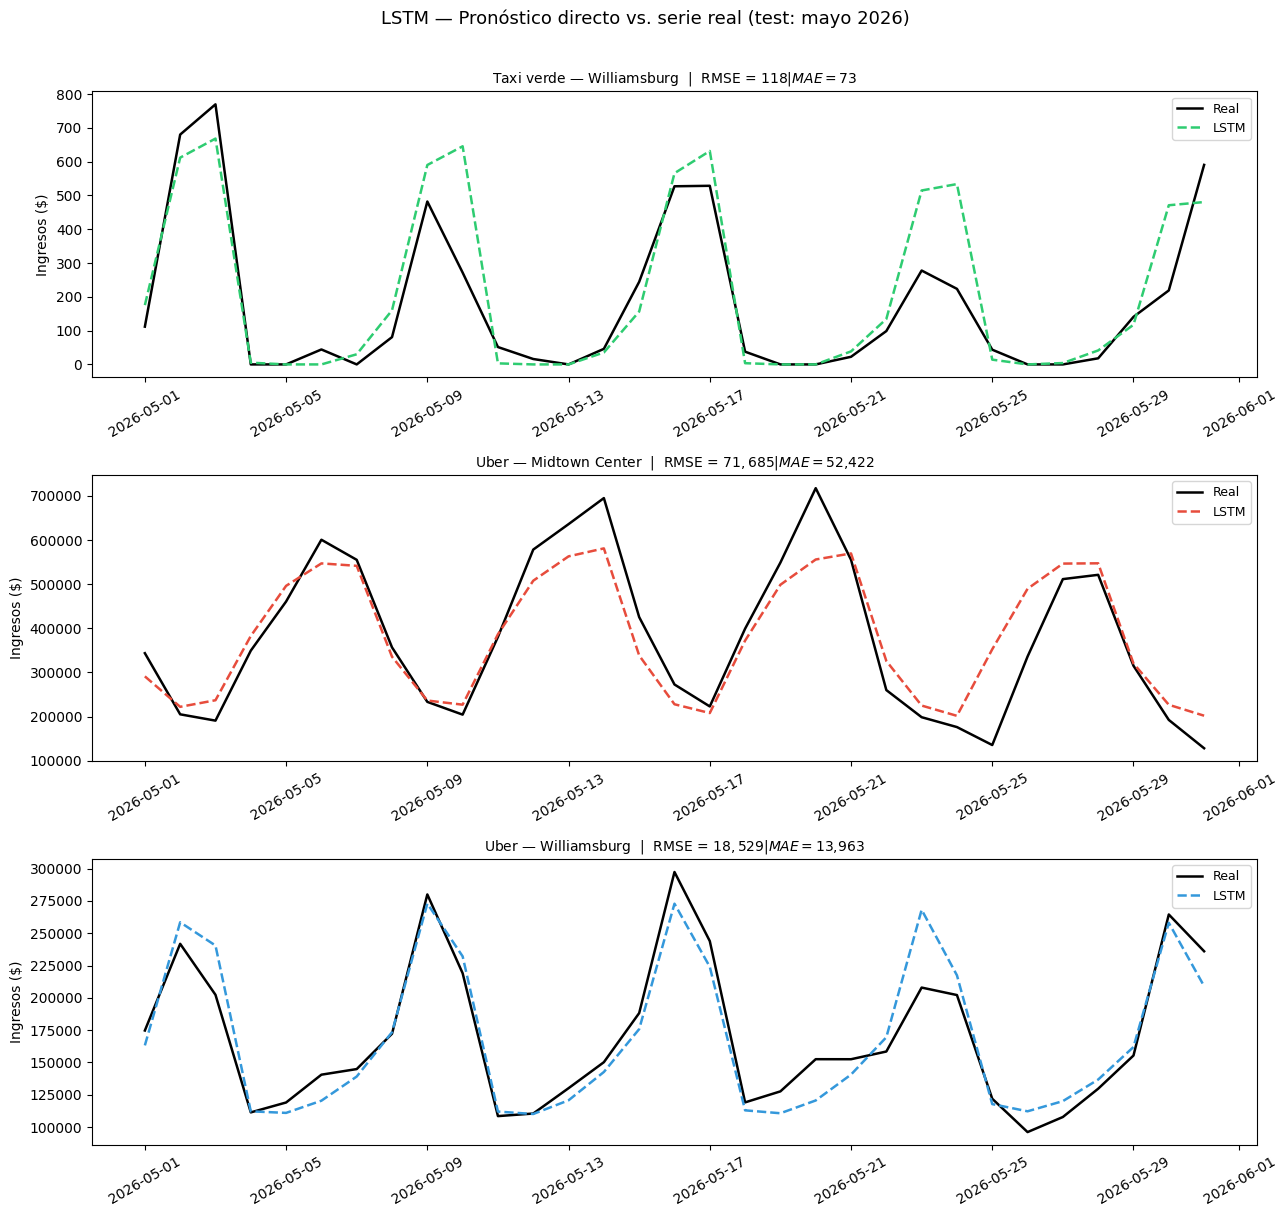

In [46]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12))
fig.suptitle(
    'LSTM — Pronóstico directo vs. serie real (test: mayo 2026)',
    fontsize=13, y=1.01
)

colores = {
    'Taxi verde — Williamsburg': '#2ecc71',
    'Uber — Williamsburg'      : '#3498db',
    'Uber — Midtown Center'    : '#e74c3c',
}

for ax, uid in zip(axes, pred_lstm_test['unique_id'].unique()):
    pred = (pred_lstm_test[pred_lstm_test['unique_id'] == uid]
            .set_index('ds')['LSTM'])
    real = (df_long_test[df_long_test['unique_id'] == uid]
            .set_index('ds')['y'])

    ax.plot(real.index,  real.values,  label='Real',  color='black', lw=1.8)
    ax.plot(pred.index,  pred.values,  label='LSTM',
            color=colores[uid], lw=1.8, linestyle='--')

    residuos = real - pred
    mae_disp  = mean_absolute_error(real.values, pred.values)
    rmse_disp = np.sqrt(mean_squared_error(real.values, pred.values))

    ax.set_title(f'{uid}  |  RMSE = ${rmse_disp:,.0f}  |  MAE = ${mae_disp:,.0f}',
                 fontsize=10)
    ax.set_ylabel('Ingresos ($)')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

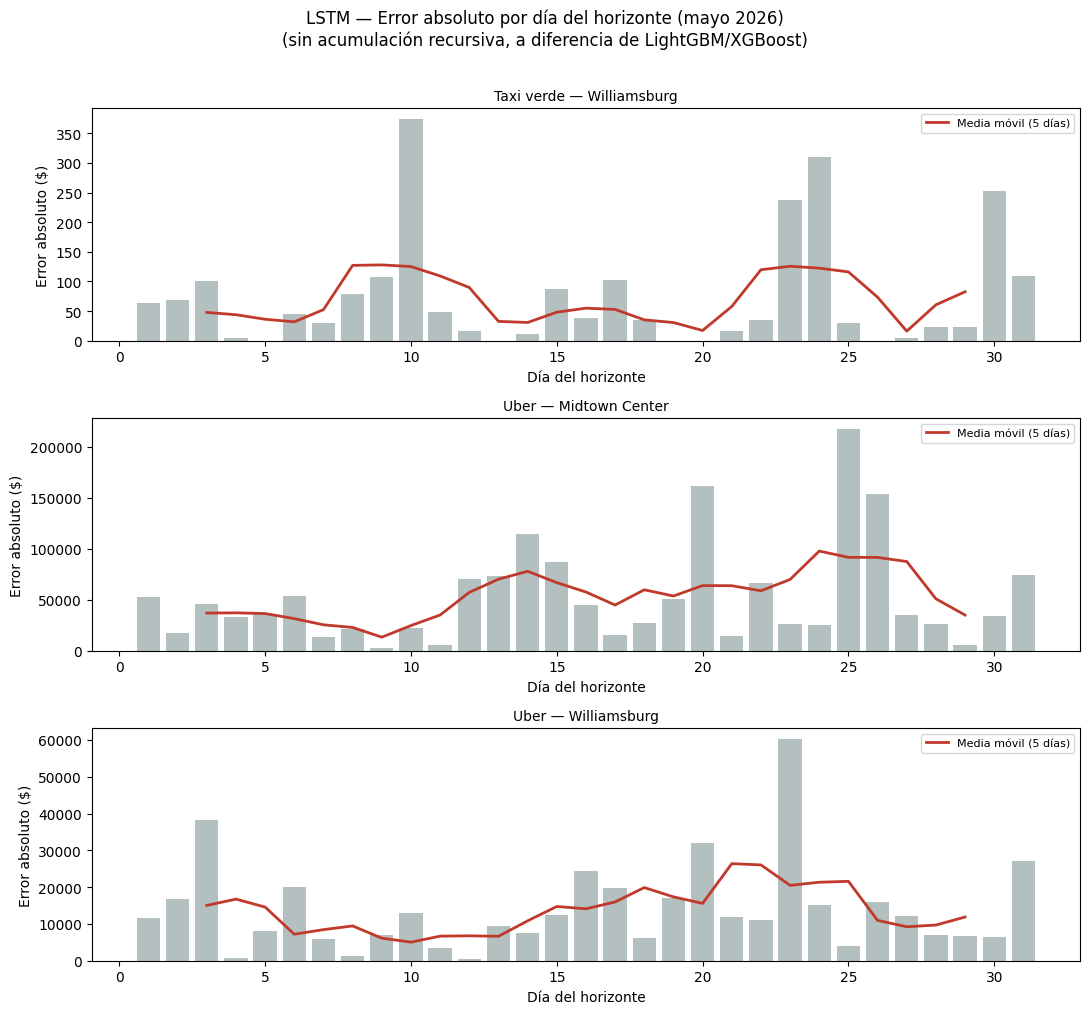

In [47]:
# (Compara directamente con la celda equivalente de LightGBM/XGBoost)

fig, axes = plt.subplots(3, 1, figsize=(11, 10))
fig.suptitle(
    'LSTM — Error absoluto por día del horizonte (mayo 2026)\n'
    '(sin acumulación recursiva, a diferencia de LightGBM/XGBoost)',
    fontsize=12, y=1.01
)

for ax, uid in zip(axes, pred_lstm_test['unique_id'].unique()):
    pred = (pred_lstm_test[pred_lstm_test['unique_id'] == uid]
            .set_index('ds')['LSTM'])
    real = (df_long_test[df_long_test['unique_id'] == uid]
            .set_index('ds')['y'])

    error_abs = (real - pred).abs().reset_index(drop=True)
    dias_horizonte = np.arange(1, len(error_abs) + 1)

    ax.bar(dias_horizonte, error_abs.values, color='#95a5a6', alpha=0.7)
    ax.plot(dias_horizonte, error_abs.rolling(5, center=True).mean(),
            color='#c0392b', lw=2, label='Media móvil (5 días)')
    ax.set_title(uid, fontsize=10)
    ax.set_xlabel('Día del horizonte')
    ax.set_ylabel('Error absoluto ($)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Diagnóstico de residuos del LSTM

Se analiza la distribución de los residuos en el test (31 observaciones por
serie) mediante:
- **QQ plot**: ¿los residuos siguen una distribución normal?
- **Residuos vs. predicho**: ¿hay heterocedasticidad (varianza del error
  dependiente del nivel predicho)?

A diferencia del SARIMAX, el LSTM no asume normalidad de los residuos, pero
el diagnóstico orienta sobre posibles deficiencias del modelo.

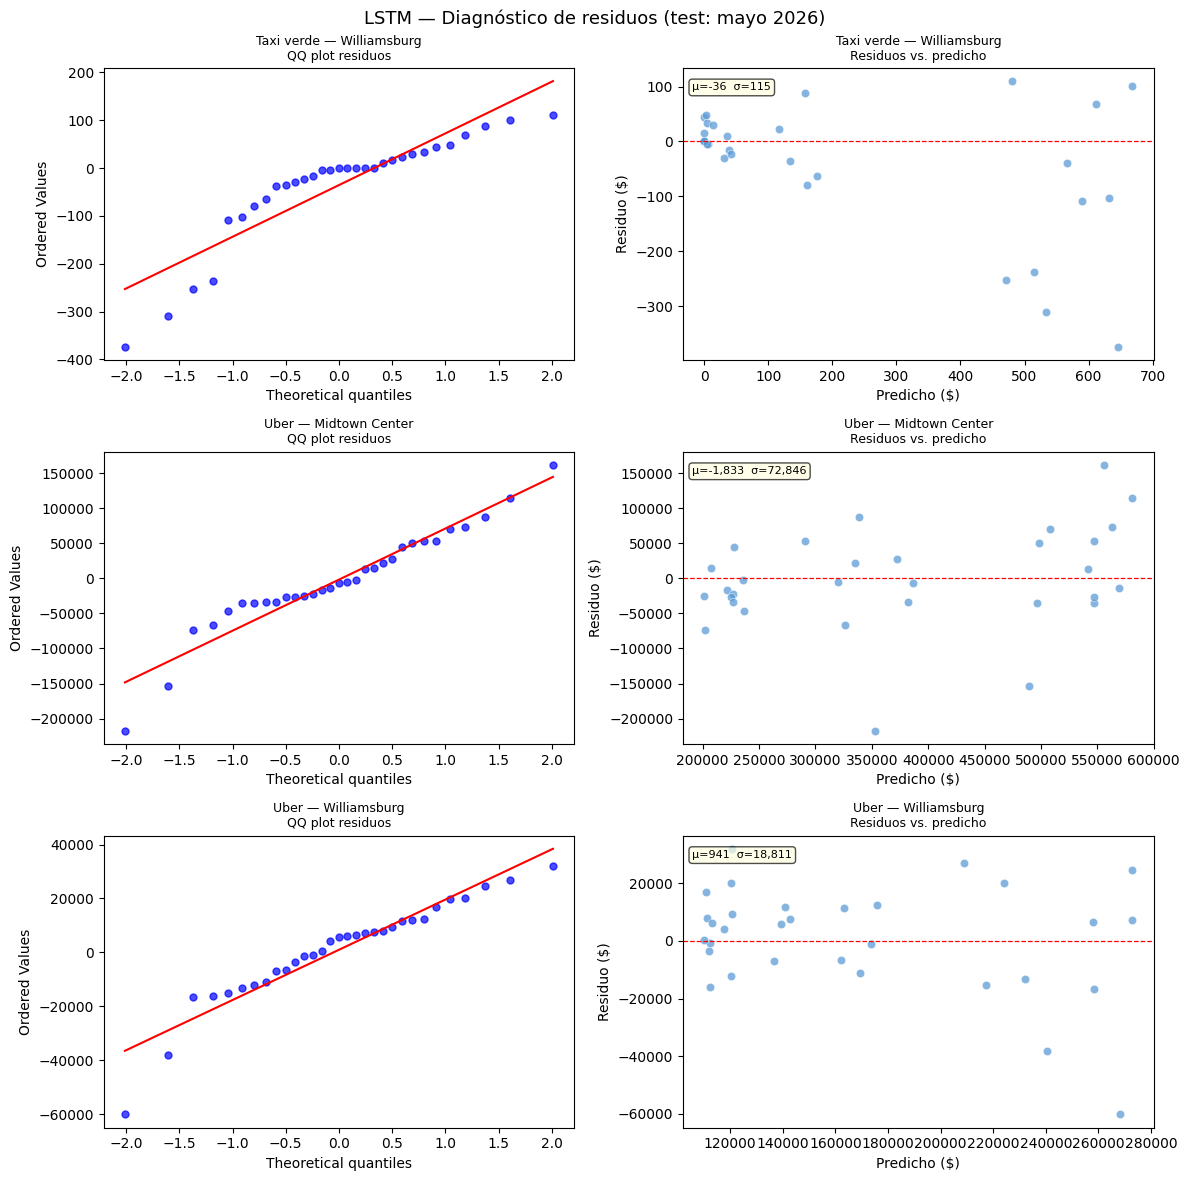

In [48]:
from scipy import stats as scipy_stats

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
fig.suptitle('LSTM — Diagnóstico de residuos (test: mayo 2026)', fontsize=13)

for i, uid in enumerate(pred_lstm_test['unique_id'].unique()):
    pred = (pred_lstm_test[pred_lstm_test['unique_id'] == uid]
            .set_index('ds')['LSTM'])
    real = (df_long_test[df_long_test['unique_id'] == uid]
            .set_index('ds')['y'])
    residuos = (real - pred).dropna()

    ax_qq, ax_res = axes[i]

    # QQ plot
    scipy_stats.probplot(residuos.values, dist='norm', plot=ax_qq)
    ax_qq.set_title(f'{uid}\nQQ plot residuos', fontsize=9)
    ax_qq.get_lines()[0].set(markersize=5, alpha=0.7)

    # Residuos vs. predicho
    ax_res.scatter(pred.values, residuos.values, alpha=0.75,
                   color='#5b9bd5', edgecolors='white', linewidths=0.4)
    ax_res.axhline(0, color='red', linestyle='--', lw=0.9)
    ax_res.set_xlabel('Predicho ($)')
    ax_res.set_ylabel('Residuo ($)')
    ax_res.set_title(f'{uid}\nResiduos vs. predicho', fontsize=9)

    # Anotación: media y desvío del residuo
    ax_res.annotate(
        f'μ={residuos.mean():,.0f}  σ={residuos.std():,.0f}',
        xy=(0.02, 0.95), xycoords='axes fraction',
        fontsize=8, va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.7)
    )

plt.tight_layout()
plt.show()

In [49]:
# Estructura compatible con df_resultados_ml (LightGBM / XGBoost)
# para la sección de comparación final.
RUTA_RESULTADOS_LSTM = DATA_DIR / 'lstm_cv' / 'resultados_lstm.csv'
df_resultados_lstm.to_csv(RUTA_RESULTADOS_LSTM, index=False)
print(f"✓ Resultados guardados → {RUTA_RESULTADOS_LSTM.name}")

print("\nResumen final LSTM:")
print(df_resultados_lstm[['Serie', 'Modelo', 'RMSE_CV', 'RMSE', 'MAE', 'MAPE%',
                            'gap_CV_test_%']].to_string(index=False))
print()
print("Variables disponibles para la sección de comparación:")
print("  df_resultados_lstm   — métricas RMSE/MAE/MAPE en test + RMSE_CV")
print("  pred_lstm_test       — predicciones diarias de mayo 2026 por serie")
print("  cv_df_lstm           — predicciones de todas las ventanas de CV")

✓ Resultados guardados → resultados_lstm.csv

Resumen final LSTM:
                    Serie Modelo   RMSE_CV     RMSE      MAE  MAPE%  gap_CV_test_%
Taxi verde — Williamsburg   LSTM    183.44   118.40    72.68  64.62          -35.5
    Uber — Midtown Center   LSTM 118763.77 71685.21 52421.73  18.36          -39.6
      Uber — Williamsburg   LSTM  39413.74 18528.65 13963.39   8.12          -53.0

Variables disponibles para la sección de comparación:
  df_resultados_lstm   — métricas RMSE/MAE/MAPE en test + RMSE_CV
  pred_lstm_test       — predicciones diarias de mayo 2026 por serie
  cv_df_lstm           — predicciones de todas las ventanas de CV
